Section 3.5.2  Sensitivity Analysis  (Option C)
Analytical curves  +  Simulated points  (N=3,000 per run)
Analytical result: h_max(R=10) = R/3 = 3.3333

[1/5] Figure 1: Response-time curves for four h values ...


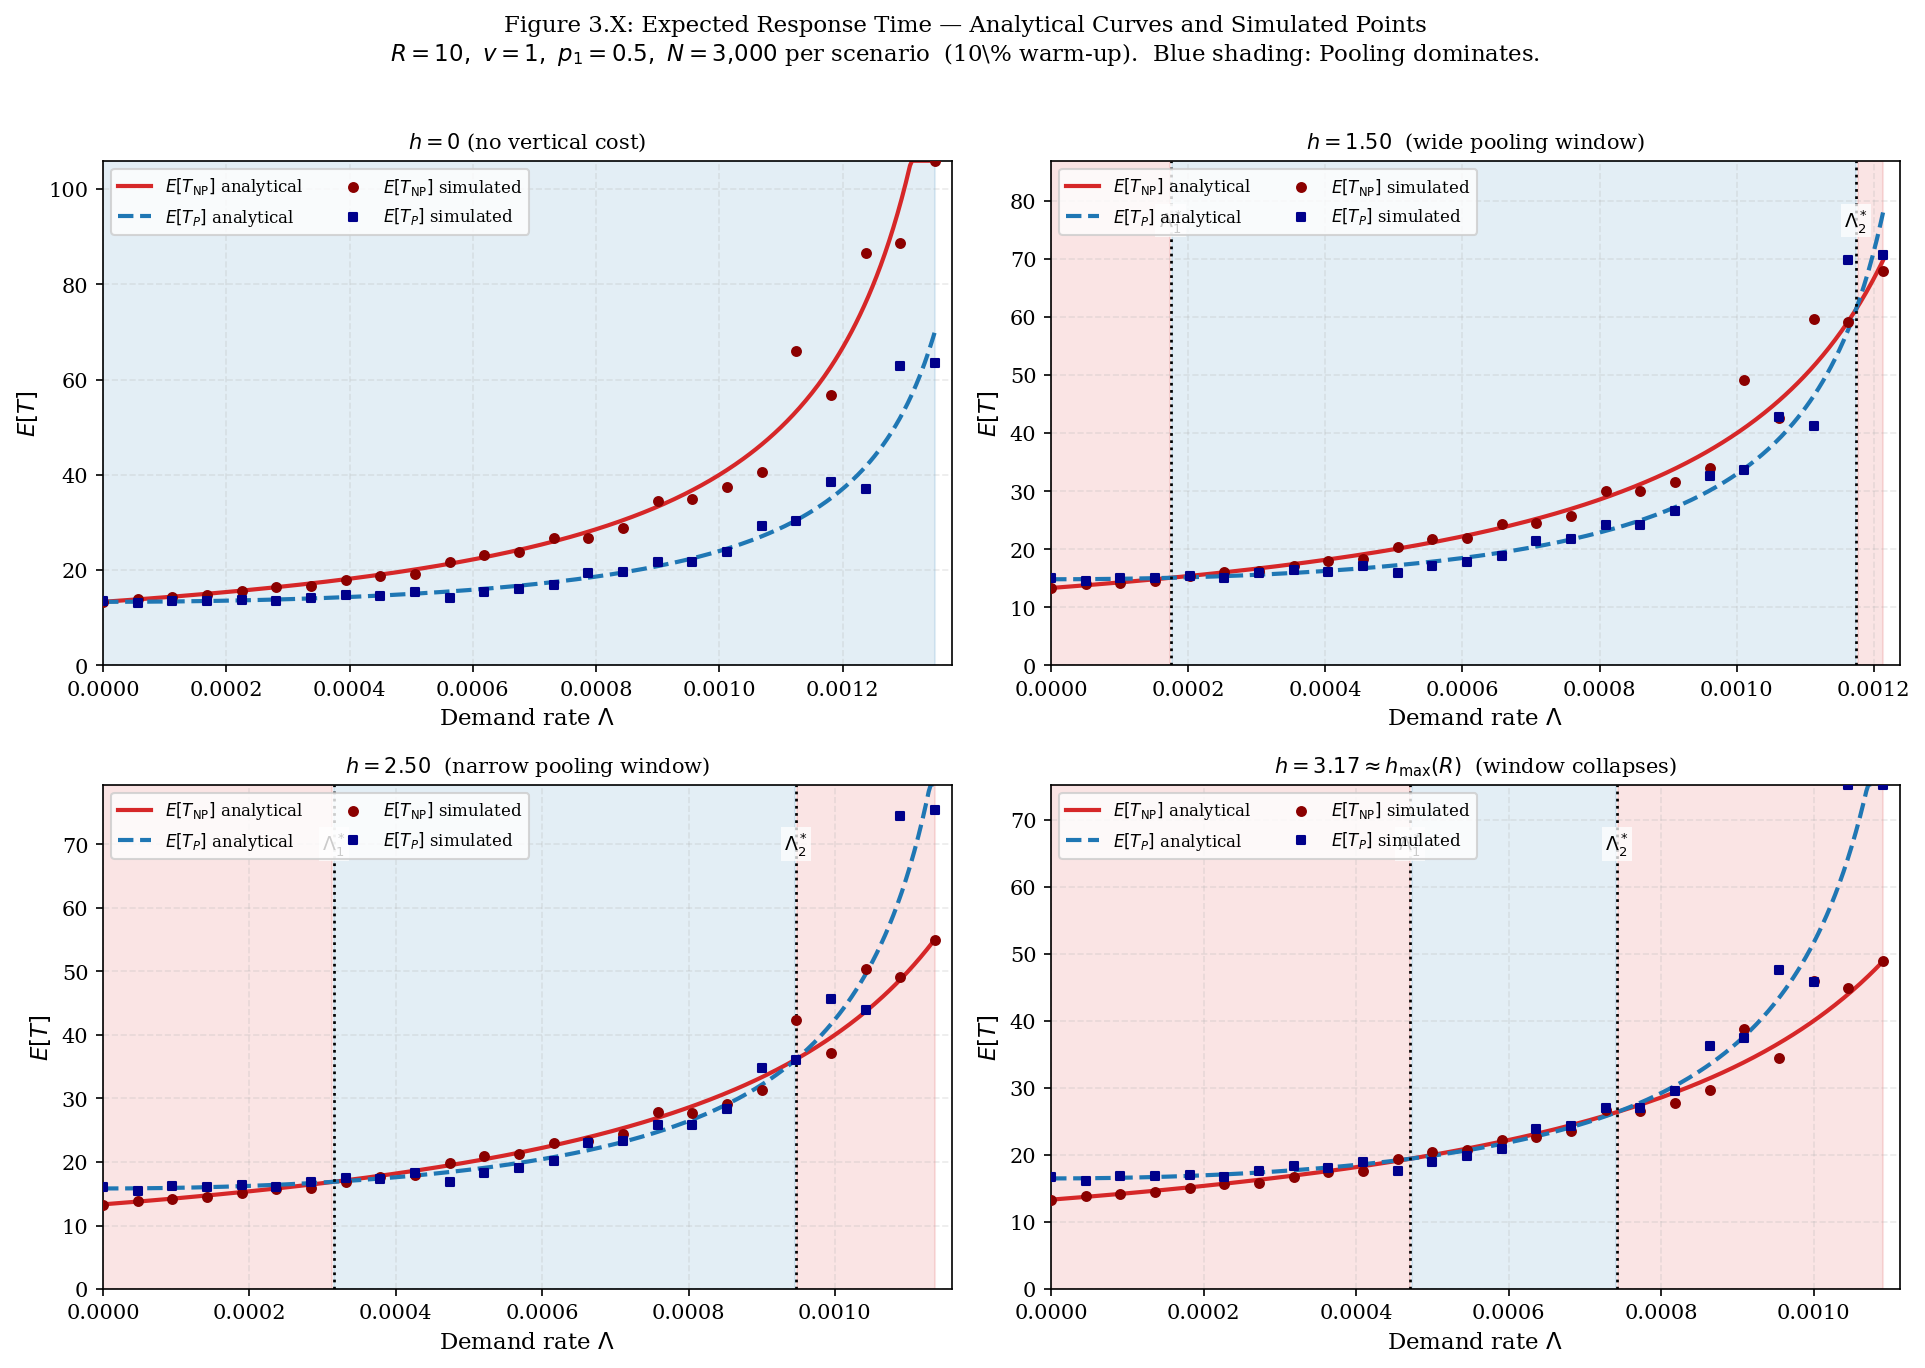

Figure 1 saved.

[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...
  Figure 2: running simulation for 7 h values...


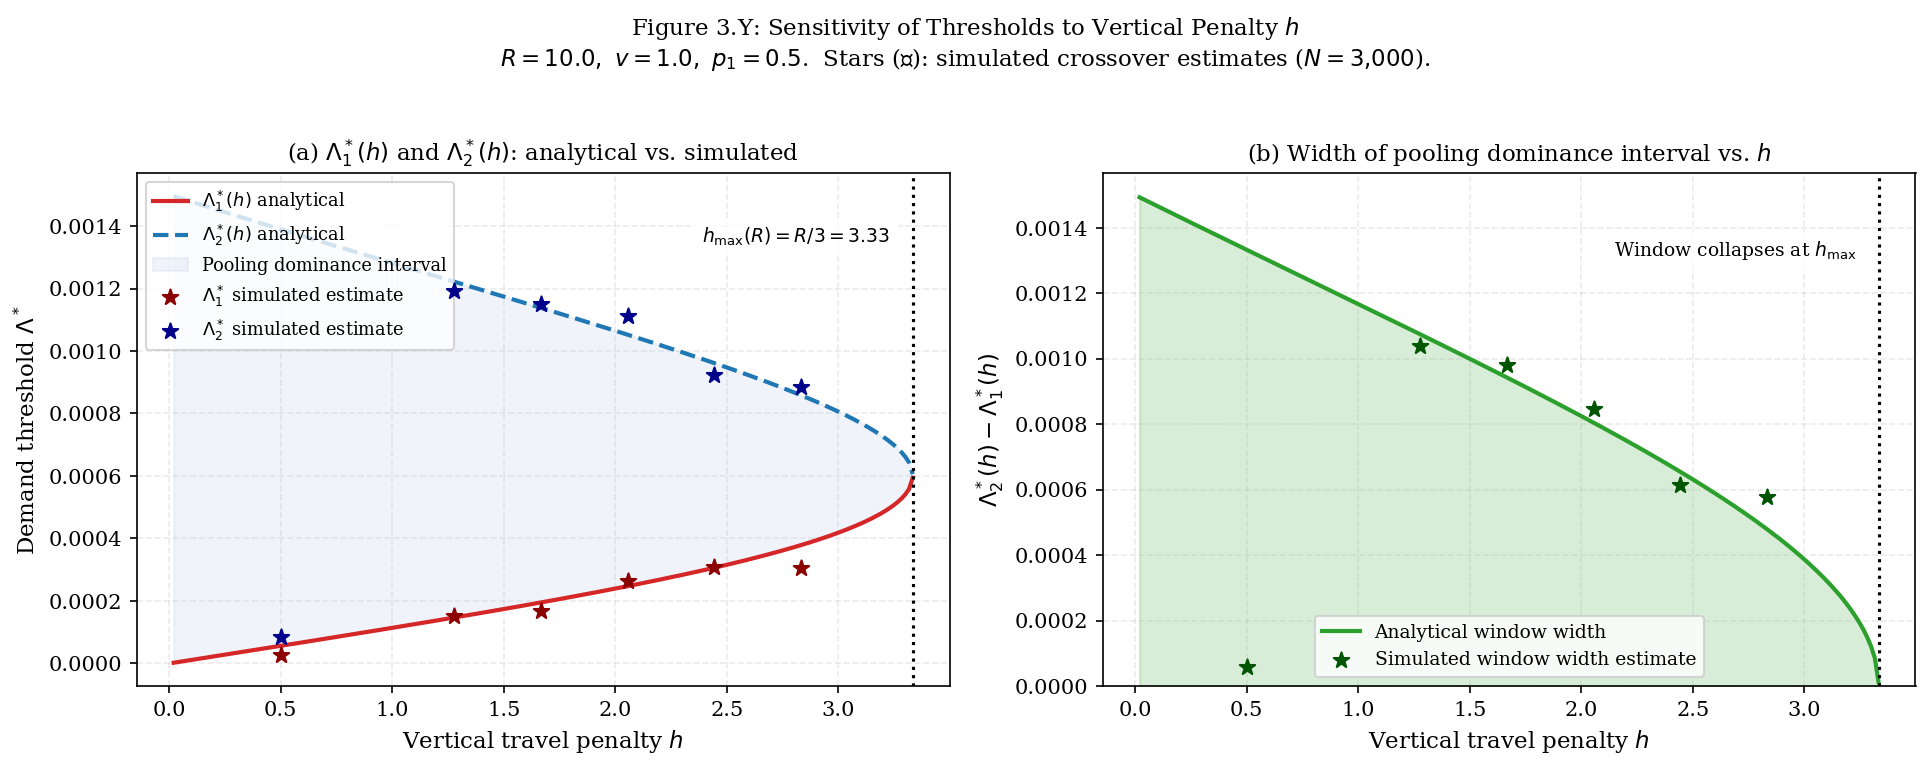

Figure 2 saved.

[3/5] Figure 3: Phase diagram in (Lambda, h) space ...


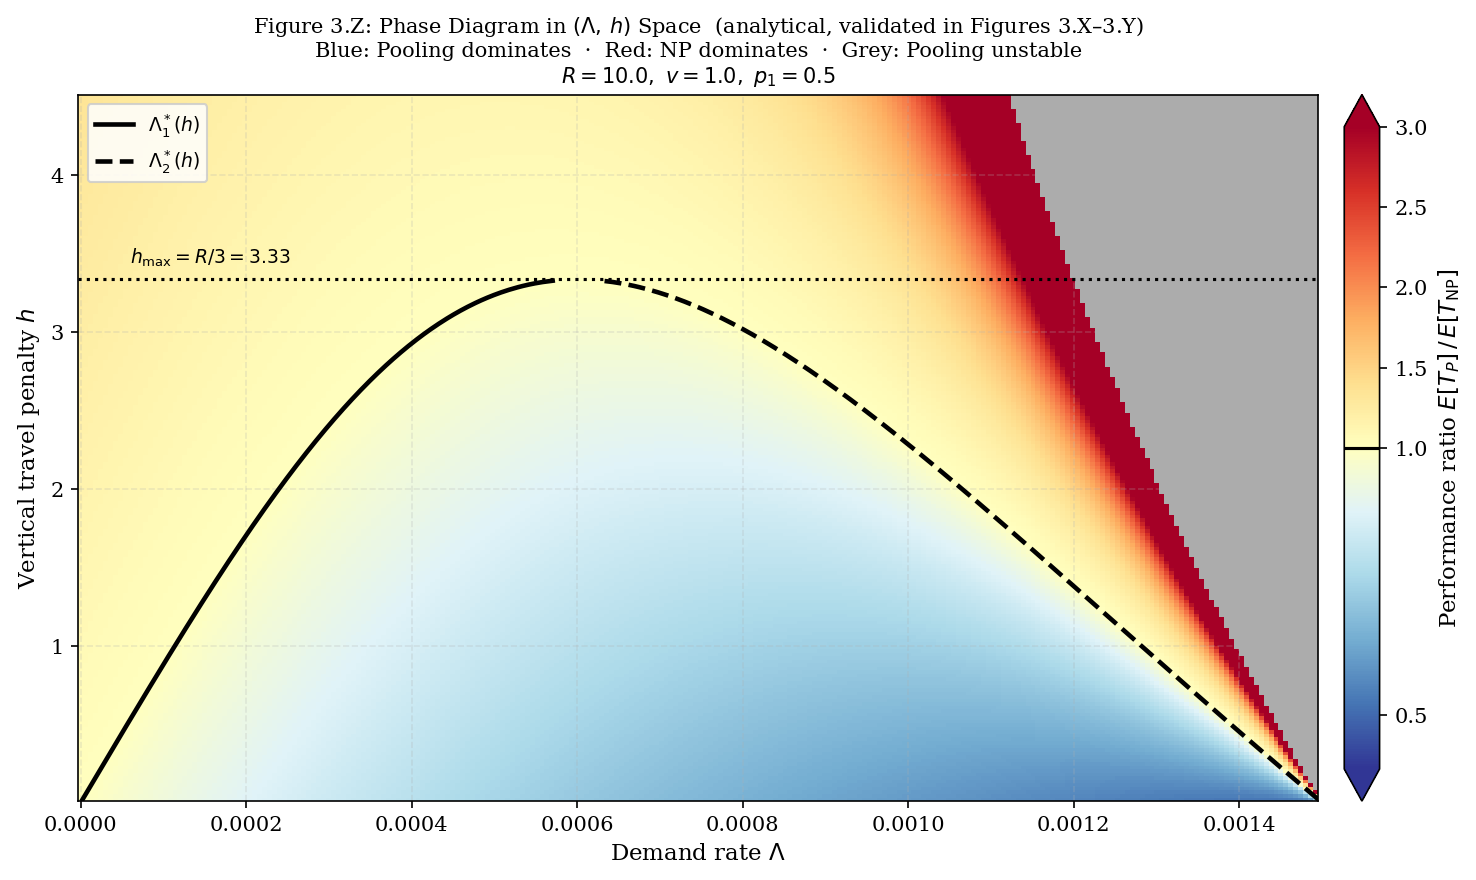

Figure 3 saved.

[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...
  Figure 4: running simulation for 7 R values...


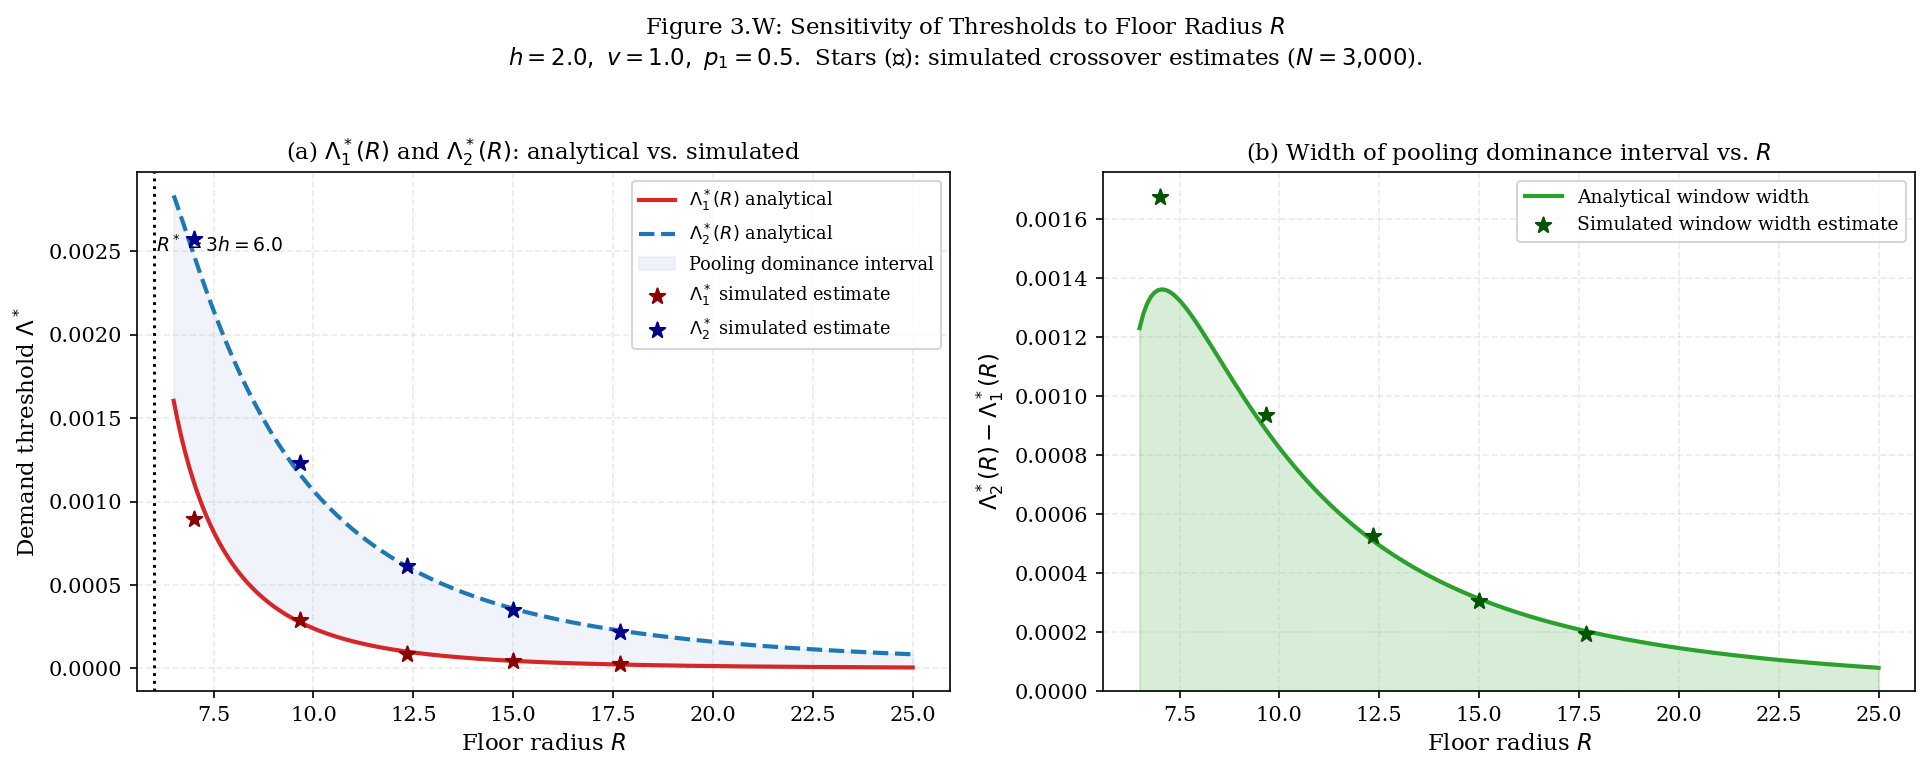

Figure 4 saved.

[5/5] Figure 5: Demand asymmetry analysis ...
  Figure 5: running simulation for 6 p₁ values × 3 regimes...


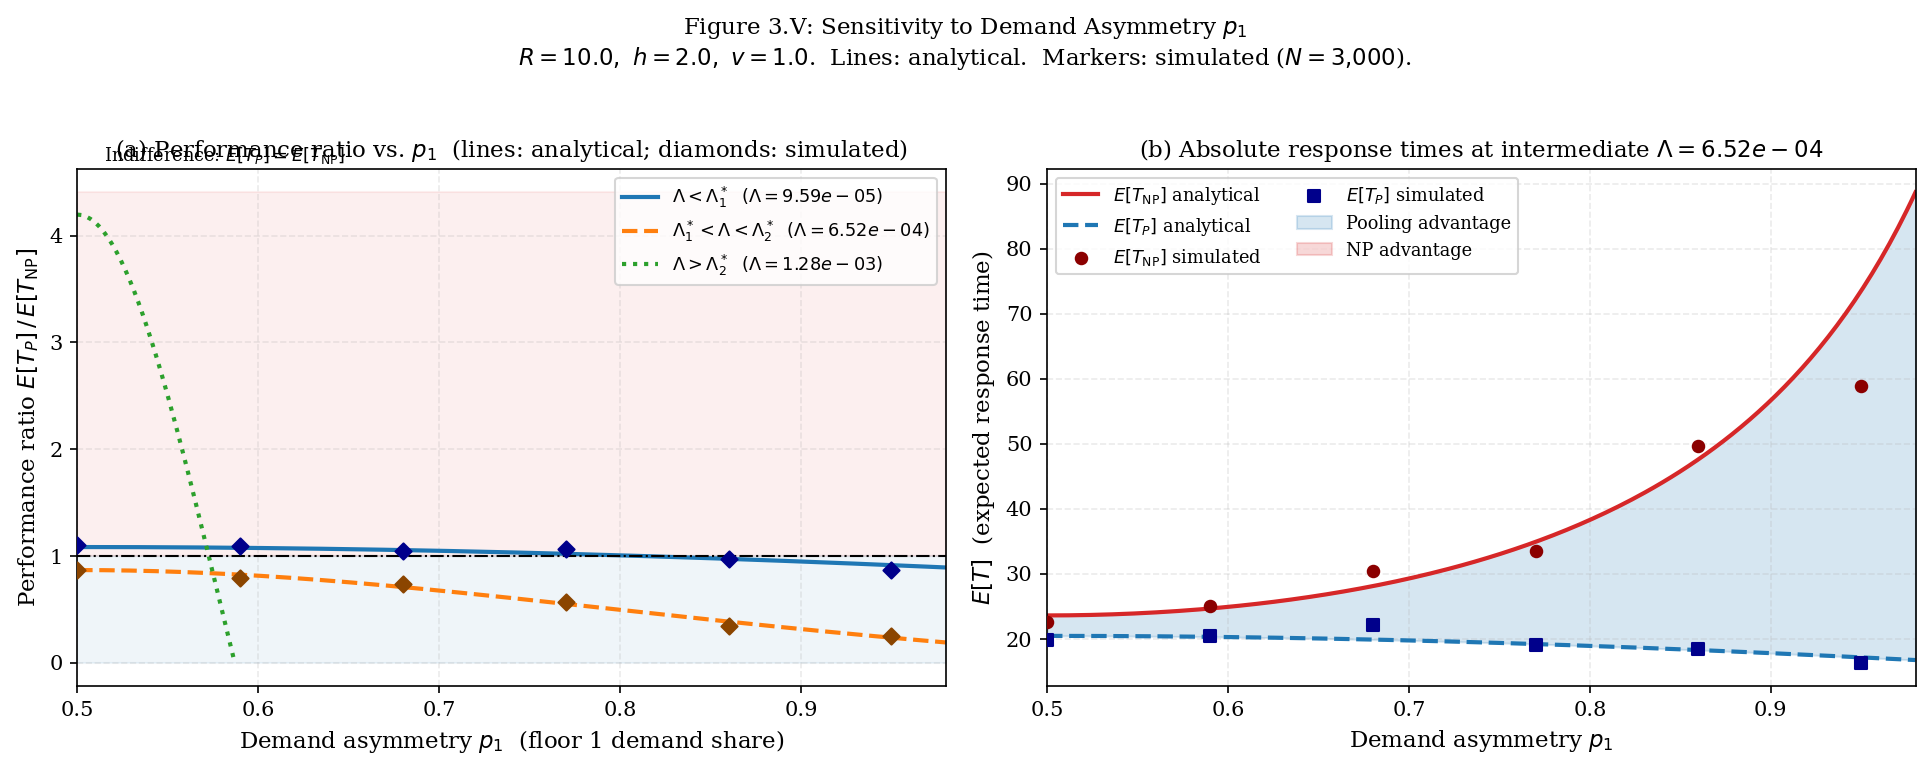

Figure 5 saved.

All 5 figures saved as PDF and PNG.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP  = '#D62728'   # red   — Non-Pooling analytical
C_P   = '#1F77B4'   # blue  — Pooling analytical
C_WIN = '#AEC7E8'   # light blue — pooling dominance shading
C_WID = '#2CA02C'   # green — window width

SIM_NP = '#8B0000'  # dark red  — Non-Pooling simulated
SIM_P  = '#00008B'  # dark blue — Pooling simulated


#  1.  ANALYTICAL MODEL  (thesis Section 3.4)


def mu_NP(R, v=1.0):
    return 3.0 * v / (4.0 * R)

def mu_P(R, h, v=1.0, p1=0.5):
    return 3.0 * v / (4.0 * R + 12.0 * p1 * (1.0 - p1) * h)

def T_NP_theory(lam, R, v=1.0, p1=0.5):
    mu = mu_NP(R, v)
    l1 = p1 * lam * R**2
    l2 = (1.0 - p1) * lam * R**2
    if l1 >= mu or l2 >= mu:
        return np.inf
    return p1 / (mu - l1) + (1.0 - p1) / (mu - l2)

def T_P_theory(lam, R, h, v=1.0, p1=0.5):
    mu  = mu_P(R, h, v, p1)
    rho = lam * R**2 / (2.0 * mu)
    if rho >= 1.0:
        return np.inf
    return 1.0 / mu + rho**2 / (mu * (1.0 - rho**2))

def thresholds_closed(R, h, v=1.0):
    """Closed-form Λ*_1, Λ*_2 (symmetric p1=0.5 only)."""
    a = mu_NP(R, v)
    b = mu_P(R, h, v, 0.5)
    disc = b * (5.0 * b - 4.0 * a)
    if disc <= 0.0:
        return None, None
    sq = np.sqrt(disc)
    x1 = (b - sq) / R**2
    x2 = (b + sq) / R**2
    if x1 <= 0.0 or x2 <= 0.0:
        return None, None
    return x1, x2

def h_max_closed(R):
    """h_max(R) = R/3  (from Proposition 3.4.X)."""
    return R / 3.0

def lim_NP(R, v=1.0, p1=0.5):
    return mu_NP(R, v) / (max(p1, 1.0 - p1) * R**2)

def lim_P(R, h, v=1.0, p1=0.5):
    return 2.0 * mu_P(R, h, v, p1) / R**2


#  2.  SIMULATION ENGINE
#      Implements the Return-to-Home policy used in Section 3.5.1.
#      N=3,000 requests; first 10% discarded as warm-up.


def simulate_NP(lam_total, R, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Non-Pooling: two independent M/M/1 queues (one per floor).
    Floor f receives arrivals at rate lam_f = p_f * lam_total * R^2.
    Service rate mu_NP = 3v/(4R).
    Returns demand-weighted mean response time (excluding warm-up).
    Returns np.inf if either floor is unstable.
    """
    rng = np.random.default_rng(seed)
    mu  = mu_NP(R, v)
    warmup = int(0.10 * N)

    total_rt = 0.0
    total_n  = 0

    for p_floor in [p1, 1.0 - p1]:
        lam_f = p_floor * lam_total * R**2
        if lam_f >= mu:
            return np.inf

        # Generate N inter-arrival and service times
        ia  = rng.exponential(1.0 / lam_f,  size=N)
        svc = rng.exponential(1.0 / mu,     size=N)

        arr = np.cumsum(ia)    # arrival times
        dep = np.empty(N)      # departure times

        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i - 1]) + svc[i]

        rt = dep - arr          # response times
        rt_trim = rt[warmup:]
        total_rt += p_floor * rt_trim.mean()
        total_n  += len(rt_trim)

    return total_rt   # demand-weighted average


def simulate_P(lam_total, R, h, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Pooling: one M/M/2 queue.
    Total arrival rate = lam_total * R^2.
    Service rate mu_P = 3v / (4R + 12*p1*(1-p1)*h).
    Returns mean response time (excluding warm-up).
    Returns np.inf if rho >= 1.
    """
    rng    = np.random.default_rng(seed)
    mu     = mu_P(R, h, v, p1)
    lam_q  = lam_total * R**2
    rho    = lam_q / (2.0 * mu)
    if rho >= 1.0:
        return np.inf

    warmup = int(0.10 * N)

    ia  = rng.exponential(1.0 / lam_q, size=N)
    svc = rng.exponential(1.0 / mu,    size=N)

    arr    = np.cumsum(ia)
    dep    = np.empty(N)
    server = np.zeros(2)    # completion times for the 2 servers

    for i in range(N):
        s = int(np.argmin(server))             # earliest free server
        start   = max(arr[i], server[s])
        dep[i]  = start + svc[i]
        server[s] = dep[i]

    rt      = dep - arr
    rt_trim = rt[warmup:]
    return rt_trim.mean()


def sim_curve(lam_arr, R, h, v=1.0, p1=0.5, N=3000, seed=0):
    """
    Run simulation for every Λ in lam_arr.
    Returns arrays (T_NP_sim, T_P_sim).
    """
    tnp = np.array([simulate_NP(l, R, v, p1, N, seed+j)
                    for j, l in enumerate(lam_arr)])
    tp  = np.array([simulate_P(l, R, h, v, p1, N, seed+1000+j)
                    for j, l in enumerate(lam_arr)])
    return tnp, tp


def theory_curve(lam_arr, R, h, v=1.0, p1=0.5):
    """Analytical curves for every Λ in lam_arr."""
    tnp = np.array([T_NP_theory(l, R, v, p1) for l in lam_arr])
    tp  = np.array([T_P_theory(l, R, h, v, p1) for l in lam_arr])
    tnp[np.isinf(tnp)] = np.nan
    tp[np.isinf(tp)]   = np.nan
    return tnp, tp


def find_sim_crossings(lam_arr, T_NP_sim, T_P_sim):
    """
    Estimate simulated crossover points (Λ*_1 and Λ*_2) by linear
    interpolation of the sign of (T_P_sim - T_NP_sim).
    Returns list of crossover Λ values.
    """
    d = T_P_sim - T_NP_sim
    crossings = []
    for i in range(len(d) - 1):
        if np.isnan(d[i]) or np.isnan(d[i + 1]):
            continue
        if d[i] * d[i + 1] < 0:
            # Linear interpolation
            frac = -d[i] / (d[i + 1] - d[i])
            crossings.append(lam_arr[i] + frac * (lam_arr[i + 1] - lam_arr[i]))
    return crossings



#  3. FIGURE 1


def figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25):

    p1  = 0.5
    hm  = h_max_closed(R)
    h_vals = [0.0, hm * 0.45, hm * 0.75, hm * 0.95]
    labels = [
        r'$h = 0$ (no vertical cost)',
        rf'$h = {hm*0.45:.2f}$  (wide pooling window)',
        rf'$h = {hm*0.75:.2f}$  (narrow pooling window)',
        rf'$h = {hm*0.95:.2f} \approx h_{{\max}}(R)$  (window collapses)',
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, h, label in zip(axes, h_vals, labels):

        lim = 0.90 * min(lim_NP(R, v, p1), lim_P(R, h, v, p1))
        lam_dense = np.linspace(1e-9, lim, 400)
        lam_sim   = np.linspace(1e-9, lim, N_LAM)

        # Analytical
        tnp_th, tp_th = theory_curve(lam_dense, R, h, v, p1)

        # Simulated
        tnp_s, tp_s = sim_curve(lam_sim, R, h, v, p1, N=N_SIM)
        tnp_s[np.isinf(tnp_s)] = np.nan
        tp_s[np.isinf(tp_s)]   = np.nan

        # y ceiling from analytical
        all_fin = np.concatenate([tnp_th[~np.isnan(tnp_th)],
                                   tp_th[~np.isnan(tp_th)]])
        y_ceil  = np.percentile(all_fin, 94) * 1.6 if len(all_fin) > 0 else 100.

        # Dominance shading (from analytical)
        valid  = ~(np.isnan(tnp_th) | np.isnan(tp_th))
        p_wins = valid & (tp_th < tnp_th)
        ax.fill_between(lam_dense, 0, y_ceil, where=p_wins,
                        alpha=0.12, color=C_P)
        ax.fill_between(lam_dense, 0, y_ceil, where=~p_wins & valid,
                        alpha=0.12, color=C_NP)

        # Analytical curves
        ax.plot(lam_dense, np.clip(tnp_th, 0, y_ceil),
                color=C_NP, lw=2.0, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}]$ analytical')
        ax.plot(lam_dense, np.clip(tp_th, 0, y_ceil),
                color=C_P, lw=2.0, linestyle='--',
                label=r'$E[T_P]$ analytical')

        # Simulated scatter
        mask = ~np.isnan(tnp_s)
        ax.scatter(lam_sim[mask], np.clip(tnp_s[mask], 0, y_ceil),
                   color=SIM_NP, s=18, zorder=5, marker='o',
                   label=r'$E[T_{\mathrm{NP}}]$ simulated')
        mask = ~np.isnan(tp_s)
        ax.scatter(lam_sim[mask], np.clip(tp_s[mask], 0, y_ceil),
                   color=SIM_P, s=18, zorder=5, marker='s',
                   label=r'$E[T_P]$ simulated')

        # Threshold markers (analytical)
        L1, L2 = thresholds_closed(R, h, v)
        for L, sym in [(L1, r'$\Lambda_1^*$'), (L2, r'$\Lambda_2^*$')]:
            if L is not None and 0 < L < lim:
                ax.axvline(L, color='black', linestyle=':', lw=1.3)
                ax.text(L, y_ceil * 0.87, sym, ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.75,
                                  edgecolor='none', pad=1.5))

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y_ceil)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$')
        ax.set_title(label, fontsize=10)
        ax.legend(loc='upper left', fontsize=8, ncol=2)

    fig.suptitle(
        r'Figure 3.X: Expected Response Time — Analytical Curves and Simulated Points'
        '\n'
        r'$R=10,\ v=1,\ p_1=0.5,\ N=3{,}000$ per scenario  '
        r'(10\% warm-up).  Blue shading: Pooling dominates.',
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig('fig1_response_time_curves.pdf', bbox_inches='tight')
    plt.savefig('fig1_response_time_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 1 saved.')


#  4. FIGURE 2


def figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=35, n_h_val=200,
            n_h_sim=7):

    p1 = 0.5
    hm = h_max_closed(R)

    # Analytical threshold curves
    h_arr  = np.linspace(0.02, hm * 0.9999, n_h_val)
    L1_th  = np.array([thresholds_closed(R, h, v)[0] for h in h_arr],
                       dtype=float)
    L2_th  = np.array([thresholds_closed(R, h, v)[1] for h in h_arr],
                       dtype=float)
    W_th   = L2_th - L1_th

    # Simulated crossover estimates at n_h_sim h values
    h_sim_vals = np.linspace(hm * 0.15, hm * 0.85, n_h_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 2: running simulation for {n_h_sim} h values...')
    for h_s in h_sim_vals:
        lim = 0.88 * min(lim_NP(R, v, p1), lim_P(R, h_s, v, p1))
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R, h_s, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: threshold curves ───────────────────────────────────
    ax1.plot(h_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(h)$ analytical')
    ax1.plot(h_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(h)$ analytical')
    ax1.fill_between(h_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')

    # Simulated crossovers
    valid = ~np.isnan(L1_sim_est)
    ax1.scatter(h_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(h_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')

    ax1.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax1.text(hm * 0.97, float(np.nanmax(L2_th)) * 0.90,
             rf'$h_{{\max}}(R) = R/3 = {hm:.2f}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax1.set_xlabel(r'Vertical travel penalty $h$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(h)$ and $\Lambda_2^*(h)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5, loc='upper left')

    # ── Right: window width ──────────────────────────────────────
    ax2.plot(h_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(h_arr, 0, W_th, alpha=0.18, color=C_WID)

    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(h_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')

    ax2.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax2.text(hm * 0.97, float(np.nanmax(W_th)) * 0.88,
             r'Window collapses at $h_{\max}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax2.set_xlabel(r'Vertical travel penalty $h$')
    ax2.set_ylabel(r'$\Lambda_2^*(h) - \Lambda_1^*(h)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $h$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    fig.suptitle(
        rf'Figure 3.Y: Sensitivity of Thresholds to Vertical Penalty $h$'
        '\n'
        rf'$R={R},\ v={v},\ p_1=0.5$.  '
        r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig2_threshold_vs_h.pdf', bbox_inches='tight')
    plt.savefig('fig2_threshold_vs_h.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 2 saved.')


#  5. FIGURE 3

def figure3(R=10.0, v=1.0, n_lam=250, n_h=200):

    p1     = 0.5
    hm     = h_max_closed(R)
    lim_np = lim_NP(R, v, p1) * 0.995

    lam_arr = np.linspace(1e-9, lim_np, n_lam)
    h_arr   = np.linspace(0.02, hm * 1.35, n_h)

    ratio_grid = np.full((n_h, n_lam), np.nan)

    for i, h in enumerate(h_arr):
        lp = lim_P(R, h, v, p1) * 0.995
        for j, lam in enumerate(lam_arr):
            tnp = T_NP_theory(lam, R, v, p1)
            tp  = T_P_theory(lam, R, h, v, p1)
            if np.isinf(tnp):
                ratio_grid[i, j] = np.nan
            elif np.isinf(tp):
                ratio_grid[i, j] = np.inf
            else:
                ratio_grid[i, j] = tp / tnp

    plot_grid = np.where(np.isinf(ratio_grid), np.nan,
                         np.clip(ratio_grid, 0.4, 3.0))
    unstable  = np.isinf(ratio_grid)

    fig, ax = plt.subplots(figsize=(10, 6))

    norm = mcolors.TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=3.0)
    im   = ax.pcolormesh(lam_arr, h_arr, plot_grid,
                         cmap='RdYlBu_r', norm=norm, shading='auto')
    ax.pcolormesh(lam_arr, h_arr,
                  np.where(unstable, 1.0, np.nan),
                  cmap='Greys', vmin=0, vmax=1.5,
                  alpha=0.55, shading='auto')

    # Overlay analytical threshold curves
    h_line  = np.linspace(0.02, hm, 400)
    L1_line = np.array([thresholds_closed(R, h, v)[0] for h in h_line],
                        dtype=float)
    L2_line = np.array([thresholds_closed(R, h, v)[1] for h in h_line],
                        dtype=float)
    ax.plot(L1_line, h_line, 'k-',  lw=2.2, label=r'$\Lambda_1^*(h)$')
    ax.plot(L2_line, h_line, 'k--', lw=2.2, label=r'$\Lambda_2^*(h)$')
    ax.axhline(hm, color='black', linestyle=':', lw=1.5)
    ax.text(lim_np * 0.04, hm * 1.02,
            rf'$h_{{\max}} = R/3 = {hm:.2f}$', fontsize=9, va='bottom')

    cbar = fig.colorbar(im, ax=ax, extend='both', fraction=0.03, pad=0.02)
    cbar.set_label(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    cbar.ax.axhline(1.0, color='black', lw=1.5)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.set_xlabel(r'Demand rate $\Lambda$')
    ax.set_ylabel(r'Vertical travel penalty $h$')
    ax.set_title(
        r'Figure 3.Z: Phase Diagram in $(\Lambda,\,h)$ Space  '
        r'(analytical, validated in Figures 3.X–3.Y)'
        '\n'
        r'Blue: Pooling dominates  ·  Red: NP dominates  ·  '
        r'Grey: Pooling unstable'
        '\n'
        rf'$R={R},\ v={v},\ p_1=0.5$',
        fontsize=10)
    plt.tight_layout()
    plt.savefig('fig3_phase_diagram.pdf', bbox_inches='tight')
    plt.savefig('fig3_phase_diagram.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 3 saved.')


#  6. FIGURE 4


def figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35,
            n_R_val=200, n_R_sim=7):

    p1    = 0.5
    R_arr = np.linspace(3.0 * h + 0.5, 25.0, n_R_val)

    L1_th = np.array([thresholds_closed(R, h, v)[0] for R in R_arr],
                      dtype=float)
    L2_th = np.array([thresholds_closed(R, h, v)[1] for R in R_arr],
                      dtype=float)
    W_th  = L2_th - L1_th

    # Simulated crossover estimates
    R_sim_vals = np.linspace(3.0 * h + 1.0, 23.0, n_R_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 4: running simulation for {n_R_sim} R values...')
    for R_s in R_sim_vals:
        lim = 0.88 * min(lim_NP(R_s, v, p1), lim_P(R_s, h, v, p1))
        if lim <= 0:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)
            continue
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R_s, h, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)
    valid      = ~np.isnan(L1_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left ─────────────────────────────────────────────────────
    ax1.plot(R_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(R)$ analytical')
    ax1.plot(R_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(R)$ analytical')
    ax1.fill_between(R_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')
    ax1.scatter(R_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(R_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')
    R_star = 3.0 * h
    ax1.axvline(R_star, color='black', linestyle=':', lw=1.4)
    ax1.text(R_star * 1.01, float(np.nanmax(L2_th)) * 0.88,
             rf'$R^* = 3h = {R_star:.1f}$', fontsize=9)
    ax1.set_xlabel(r'Floor radius $R$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(R)$ and $\Lambda_2^*(R)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5)

    # ── Right ────────────────────────────────────────────────────
    ax2.plot(R_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(R_arr, 0, W_th, alpha=0.18, color=C_WID)
    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(R_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')
    ax2.set_xlabel(r'Floor radius $R$')
    ax2.set_ylabel(r'$\Lambda_2^*(R) - \Lambda_1^*(R)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $R$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    fig.suptitle(
        rf'Figure 3.W: Sensitivity of Thresholds to Floor Radius $R$'
        '\n'
        rf'$h={h},\ v={v},\ p_1=0.5$.  '
        r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig4_threshold_vs_R.pdf', bbox_inches='tight')
    plt.savefig('fig4_threshold_vs_R.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 4 saved.')


#  7. FIGURE 5


def figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6):

    # Symmetric thresholds for regime selection
    L1_s, L2_s = thresholds_closed(R, h, v)
    if L1_s is None or L2_s is None:
        print(f'No thresholds: need h < R/3 = {R/3:.2f}.')
        return

    lam_regimes = {
        rf'$\Lambda < \Lambda_1^*$  '
        rf'$(\Lambda={L1_s*0.40:.2e})$': L1_s * 0.40,

        rf'$\Lambda_1^* < \Lambda < \Lambda_2^*$  '
        rf'$(\Lambda={0.5*(L1_s+L2_s):.2e})$': 0.5 * (L1_s + L2_s),

        rf'$\Lambda > \Lambda_2^*$  '
        rf'$(\Lambda={L2_s*1.20:.2e})$': L2_s * 1.20,
    }

    p1_th  = np.linspace(0.50, 0.98, 200)   # dense for analytical
    p1_sim = np.linspace(0.50, 0.95, n_p)   # coarse for simulation

    styles = ['-', '--', ':']
    cols   = ['#1F77B4', '#FF7F0E', '#2CA02C']
    scols  = ['#00008B', '#8B4500', '#004400']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: performance ratio vs p₁ ───────────────────────────
    print(f'  Figure 5: running simulation for {n_p} p₁ values × 3 regimes...')
    for (label, lam), ls, col, scol in zip(
            lam_regimes.items(), styles, cols, scols):

        # Analytical ratio
        ratios_th = []
        for p in p1_th:
            lnp = lim_NP(R, v, p)
            lp  = lim_P(R, h, v, p)
            if lam >= min(lnp, lp):
                ratios_th.append(np.nan)
                continue
            tnp = T_NP_theory(lam, R, v, p)
            tp  = T_P_theory(lam, R, h, v, p)
            ratios_th.append(tp / tnp if not (np.isinf(tnp) or np.isinf(tp))
                             else np.nan)
        ax1.plot(p1_th, ratios_th, lw=2, linestyle=ls, color=col,
                 label=label)

        # Simulated ratio
        ratios_sim = []
        for p in p1_sim:
            lnp = lim_NP(R, v, p)
            lp  = lim_P(R, h, v, p)
            if lam >= min(lnp, lp) * 0.90:
                ratios_sim.append(np.nan)
                continue
            tnp_s = simulate_NP(lam, R, v, p, N=N_SIM)
            tp_s  = simulate_P(lam, R, h, v, p, N=N_SIM)
            ratios_sim.append(tp_s / tnp_s
                              if not (np.isinf(tnp_s) or np.isinf(tp_s))
                              else np.nan)
        ratios_sim = np.array(ratios_sim)
        valid = ~np.isnan(ratios_sim)
        ax1.scatter(p1_sim[valid], ratios_sim[valid],
                    color=scol, s=30, zorder=5, marker='D')

    ax1.axhline(1.0, color='black', lw=1.0, linestyle='-.')
    ax1.text(0.515, 1.015,
             r'Indifference: $E[T_P] = E[T_{\mathrm{NP}}]$',
             fontsize=8.5, transform=ax1.get_xaxis_transform())
    y1_lo, y1_hi = ax1.get_ylim()
    ax1.fill_between([0.5, 0.98], 0.0, 1.0, alpha=0.07, color=C_P)
    ax1.fill_between([0.5, 0.98], 1.0, max(y1_hi, 2.0),
                     alpha=0.07, color=C_NP)
    ax1.set_xlim(0.5, 0.98)
    ax1.set_xlabel(r'Demand asymmetry $p_1$  (floor 1 demand share)')
    ax1.set_ylabel(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    ax1.set_title(
        r'(a) Performance ratio vs. $p_1$  '
        r'(lines: analytical; diamonds: simulated)')
    ax1.legend(fontsize=8.5, loc='upper right')

    # ── Right: absolute response times at intermediate Λ ────────
    lam_mid = 0.5 * (L1_s + L2_s)
    tnp_th_v, tp_th_v = [], []
    tnp_sim_v, tp_sim_v = [], []

    for p in p1_th:
        lnp = lim_NP(R, v, p); lp = lim_P(R, h, v, p)
        if lam_mid >= min(lnp, lp):
            tnp_th_v.append(np.nan); tp_th_v.append(np.nan)
        else:
            tnp_th_v.append(T_NP_theory(lam_mid, R, v, p))
            tp_th_v.append(T_P_theory(lam_mid, R, h, v, p))

    for p in p1_sim:
        lnp = lim_NP(R, v, p); lp = lim_P(R, h, v, p)
        if lam_mid >= min(lnp, lp) * 0.90:
            tnp_sim_v.append(np.nan); tp_sim_v.append(np.nan)
        else:
            tnp_sim_v.append(simulate_NP(lam_mid, R, v, p, N=N_SIM))
            tp_sim_v.append(simulate_P(lam_mid, R, h, v, p, N=N_SIM))

    tnp_th_v = np.array(tnp_th_v)
    tp_th_v  = np.array(tp_th_v)
    tnp_sim_v = np.array(tnp_sim_v, dtype=float)
    tp_sim_v  = np.array(tp_sim_v,  dtype=float)
    tnp_th_v[np.isinf(tnp_th_v)] = np.nan
    tp_th_v[np.isinf(tp_th_v)]   = np.nan
    tnp_sim_v[np.isinf(tnp_sim_v)] = np.nan
    tp_sim_v[np.isinf(tp_sim_v)]   = np.nan

    ax2.plot(p1_th, tnp_th_v, color=C_NP, lw=2,
             label=r'$E[T_{\mathrm{NP}}]$ analytical')
    ax2.plot(p1_th, tp_th_v,  color=C_P,  lw=2, linestyle='--',
             label=r'$E[T_P]$ analytical')

    v_np = ~np.isnan(tnp_sim_v)
    v_p  = ~np.isnan(tp_sim_v)
    ax2.scatter(p1_sim[v_np], tnp_sim_v[v_np],
                color=SIM_NP, s=30, zorder=5, marker='o',
                label=r'$E[T_{\mathrm{NP}}]$ simulated')
    ax2.scatter(p1_sim[v_p], tp_sim_v[v_p],
                color=SIM_P, s=30, zorder=5, marker='s',
                label=r'$E[T_P]$ simulated')

    # Shade advantage region
    p_adv = tp_th_v < tnp_th_v
    ax2.fill_between(p1_th, tp_th_v, tnp_th_v,
                     where= p_adv, alpha=0.18, color=C_P,
                     label='Pooling advantage')
    ax2.fill_between(p1_th, tp_th_v, tnp_th_v,
                     where=~p_adv, alpha=0.18, color=C_NP,
                     label='NP advantage')

    ax2.set_xlim(0.5, 0.98)
    ax2.set_xlabel(r'Demand asymmetry $p_1$')
    ax2.set_ylabel(r'$E[T]$  (expected response time)')
    ax2.set_title(
        rf'(b) Absolute response times at intermediate '
        rf'$\Lambda = {lam_mid:.2e}$')
    ax2.legend(fontsize=8.5, ncol=2)

    fig.suptitle(
        r'Figure 3.V: Sensitivity to Demand Asymmetry $p_1$'
        '\n'
        rf'$R={R},\ h={h},\ v={v}$.  '
        r'Lines: analytical.  Markers: simulated ($N=3{,}000$).',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig5_demand_asymmetry.pdf', bbox_inches='tight')
    plt.savefig('fig5_demand_asymmetry.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 5 saved.')


#


if __name__ == '__main__':

    print('=' * 65)
    print('Section 3.5.2  Sensitivity Analysis  (Option C)')
    print('Analytical curves  +  Simulated points  (N=3,000 per run)')
    print(f'Analytical result: h_max(R=10) = R/3 = {h_max_closed(10):.4f}')
    print('=' * 65)

    print('\n[1/5] Figure 1: Response-time curves for four h values ...')
    figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25)

    print('\n[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...')
    figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=35, n_h_sim=7)

    print('\n[3/5] Figure 3: Phase diagram in (Lambda, h) space ...')
    figure3(R=10.0, v=1.0)

    print('\n[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...')
    figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35, n_R_sim=7)

    print('\n[5/5] Figure 5: Demand asymmetry analysis ...')
    figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6)

    print('\nAll 5 figures saved as PDF and PNG.')


Section 3.5.2  Sensitivity Analysis  (Option C)
Analytical curves  +  Simulated points  (N=3,000 per run)
Analytical result: h_max(R=10) = R/3 = 3.3333

[1/5] Figure 1: Response-time curves for four h values ...


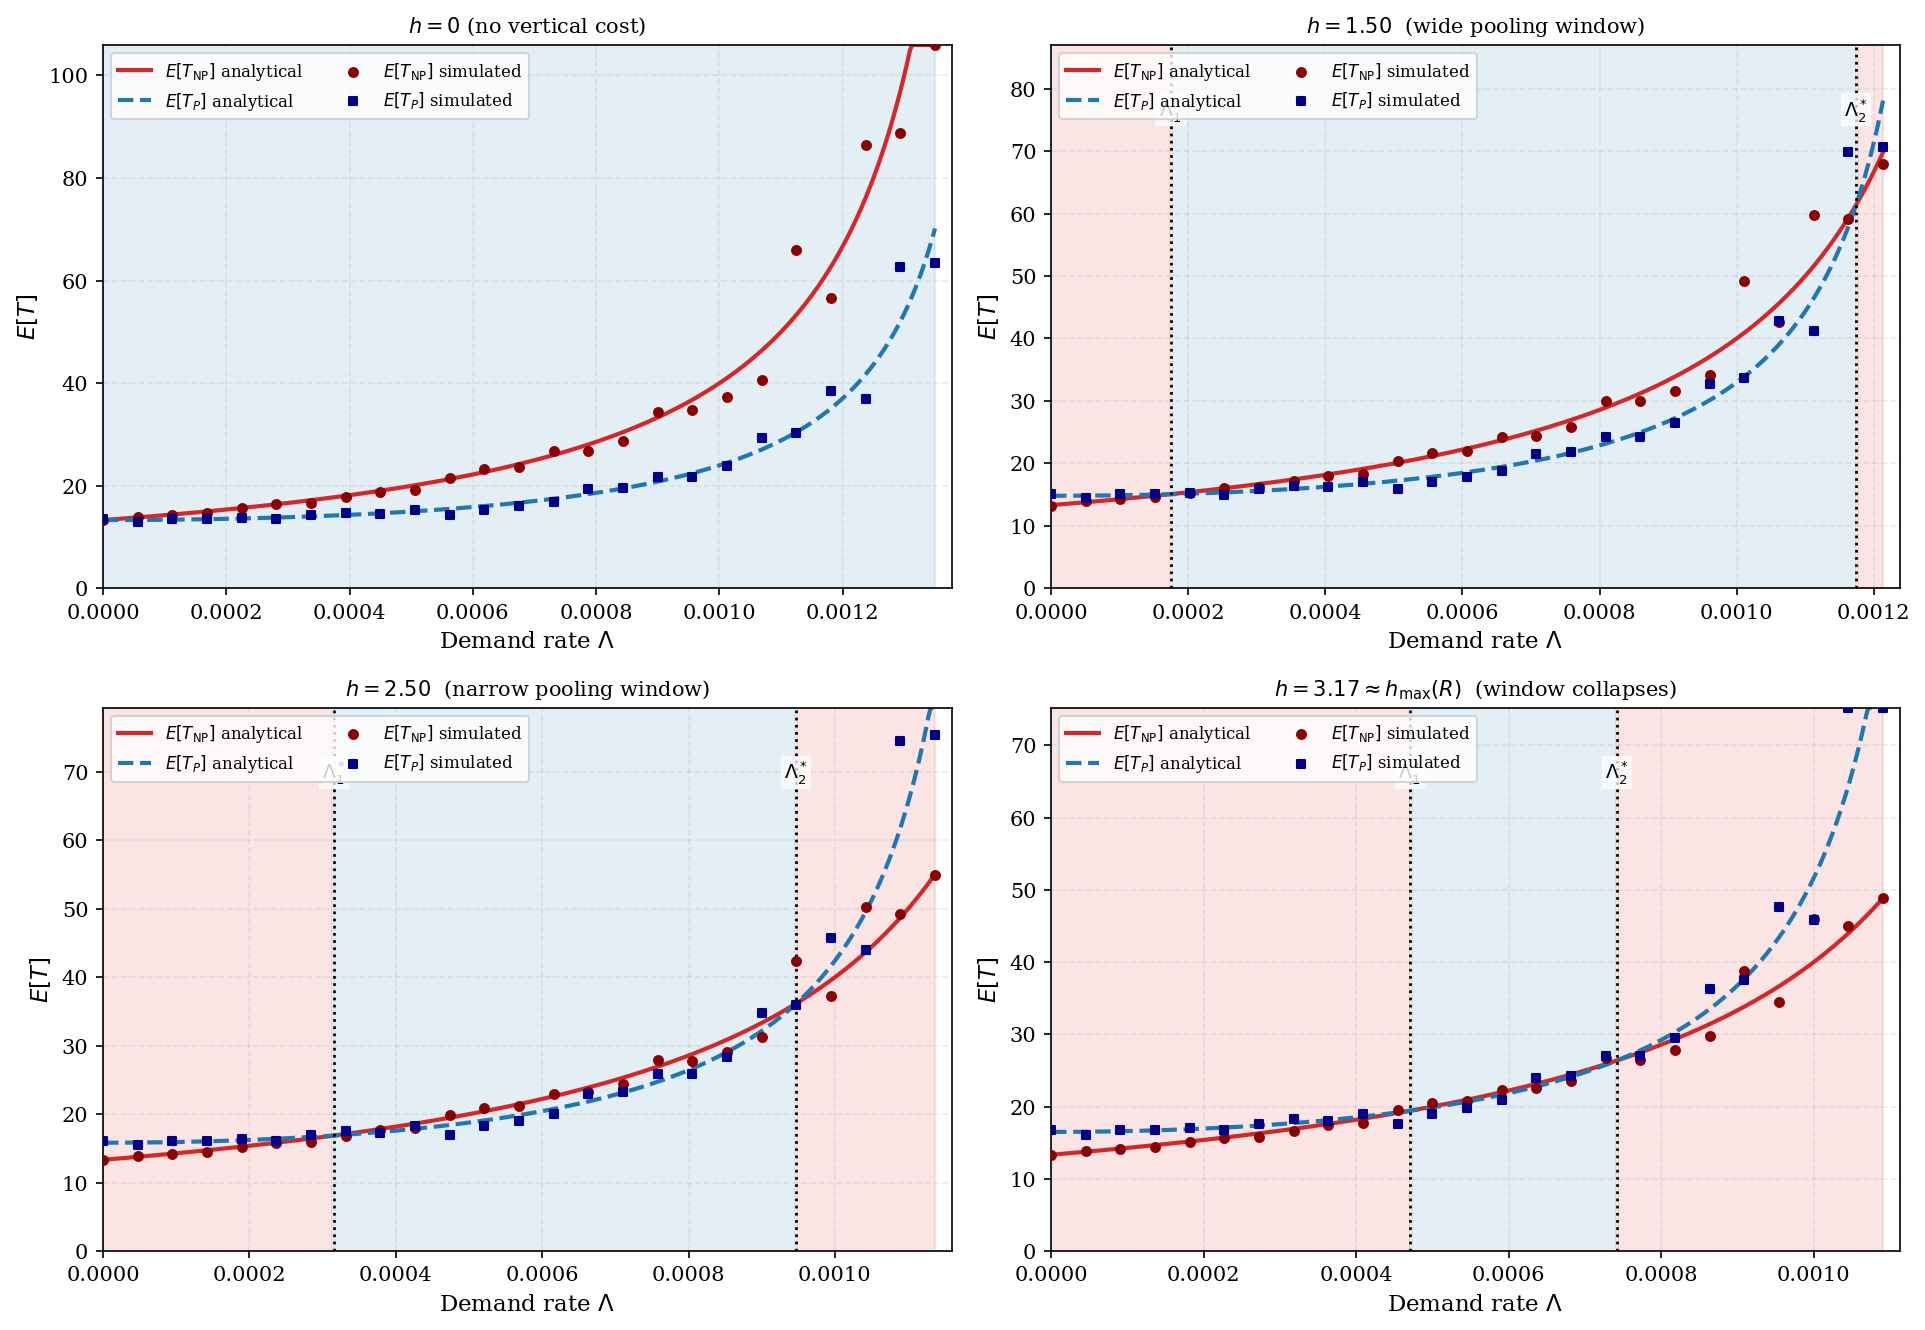

Figure 1 saved.

[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...
  Figure 2: running simulation for 7 h values...


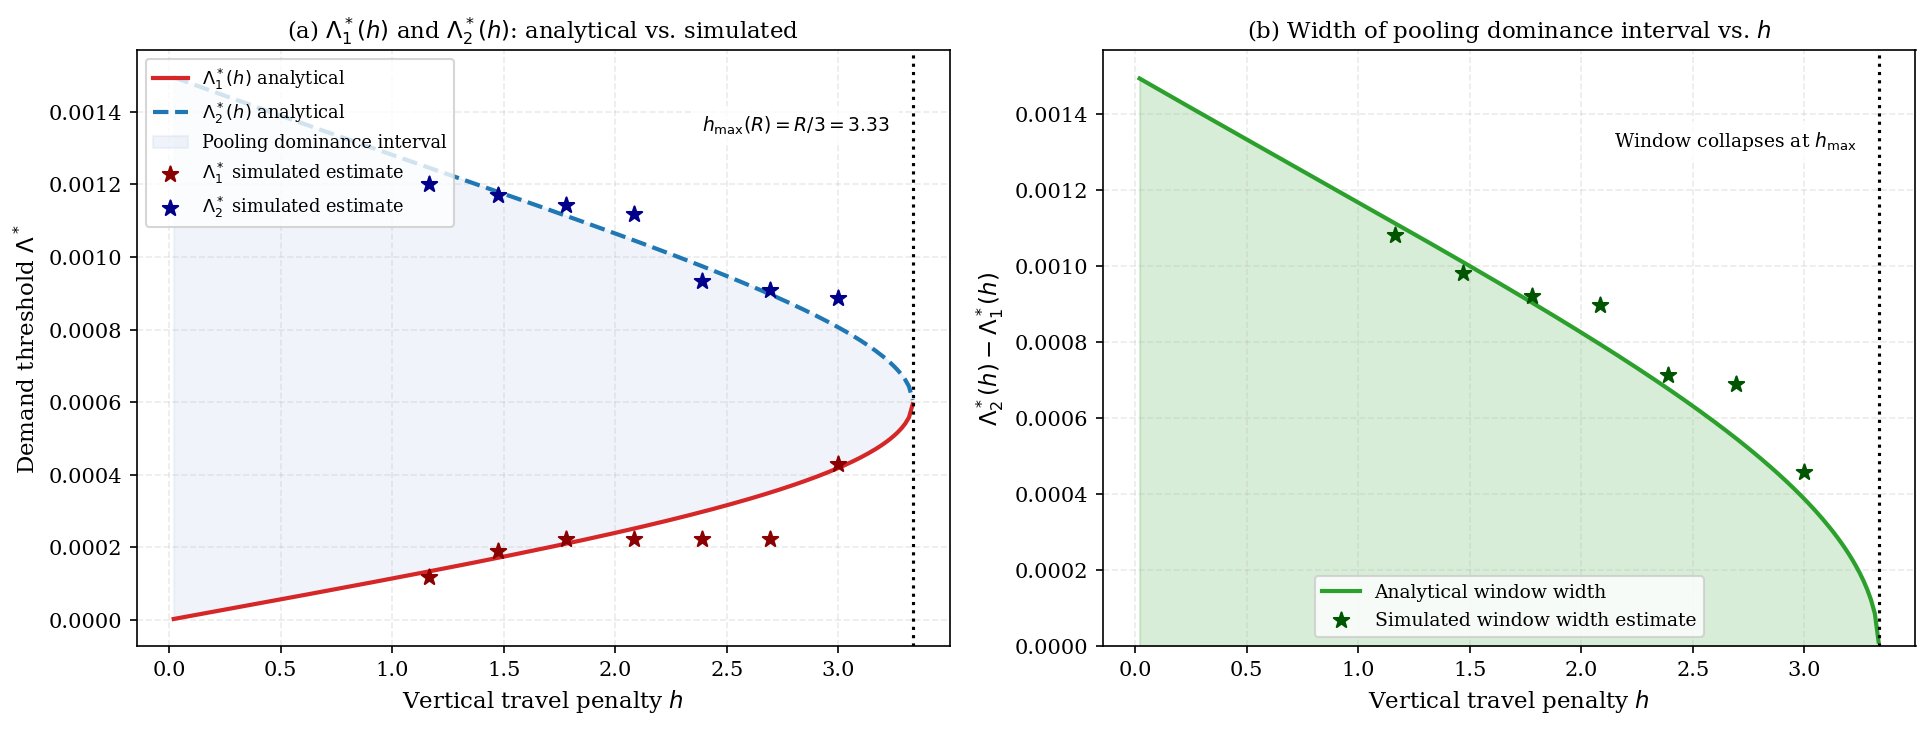

Figure 2 saved.

[3/5] Figure 3: Phase diagram in (Lambda, h) space ...


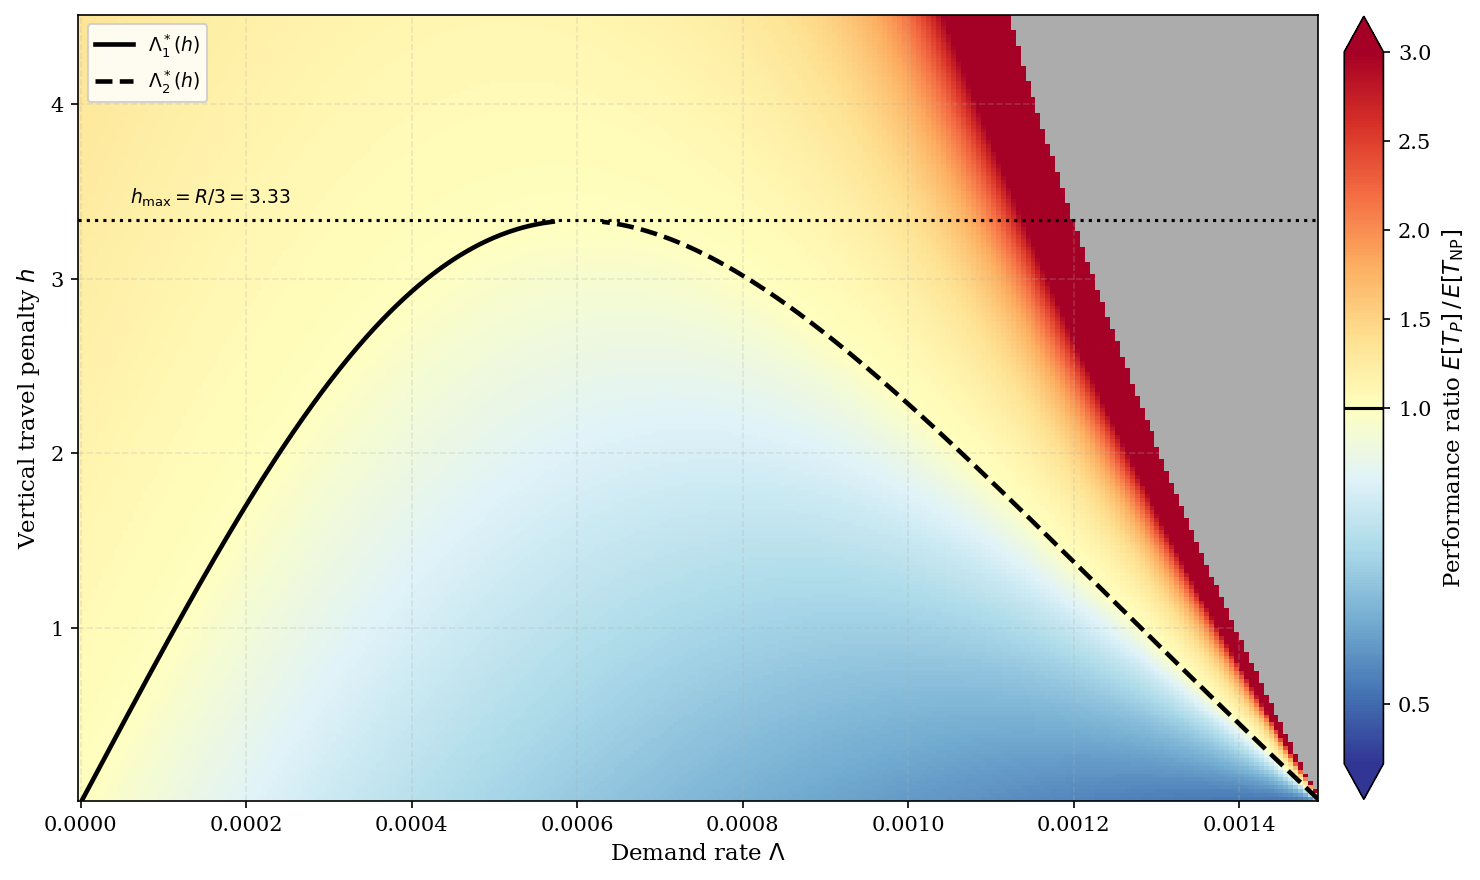

Figure 3 saved.

[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...
  Figure 4: running simulation for 7 R values...


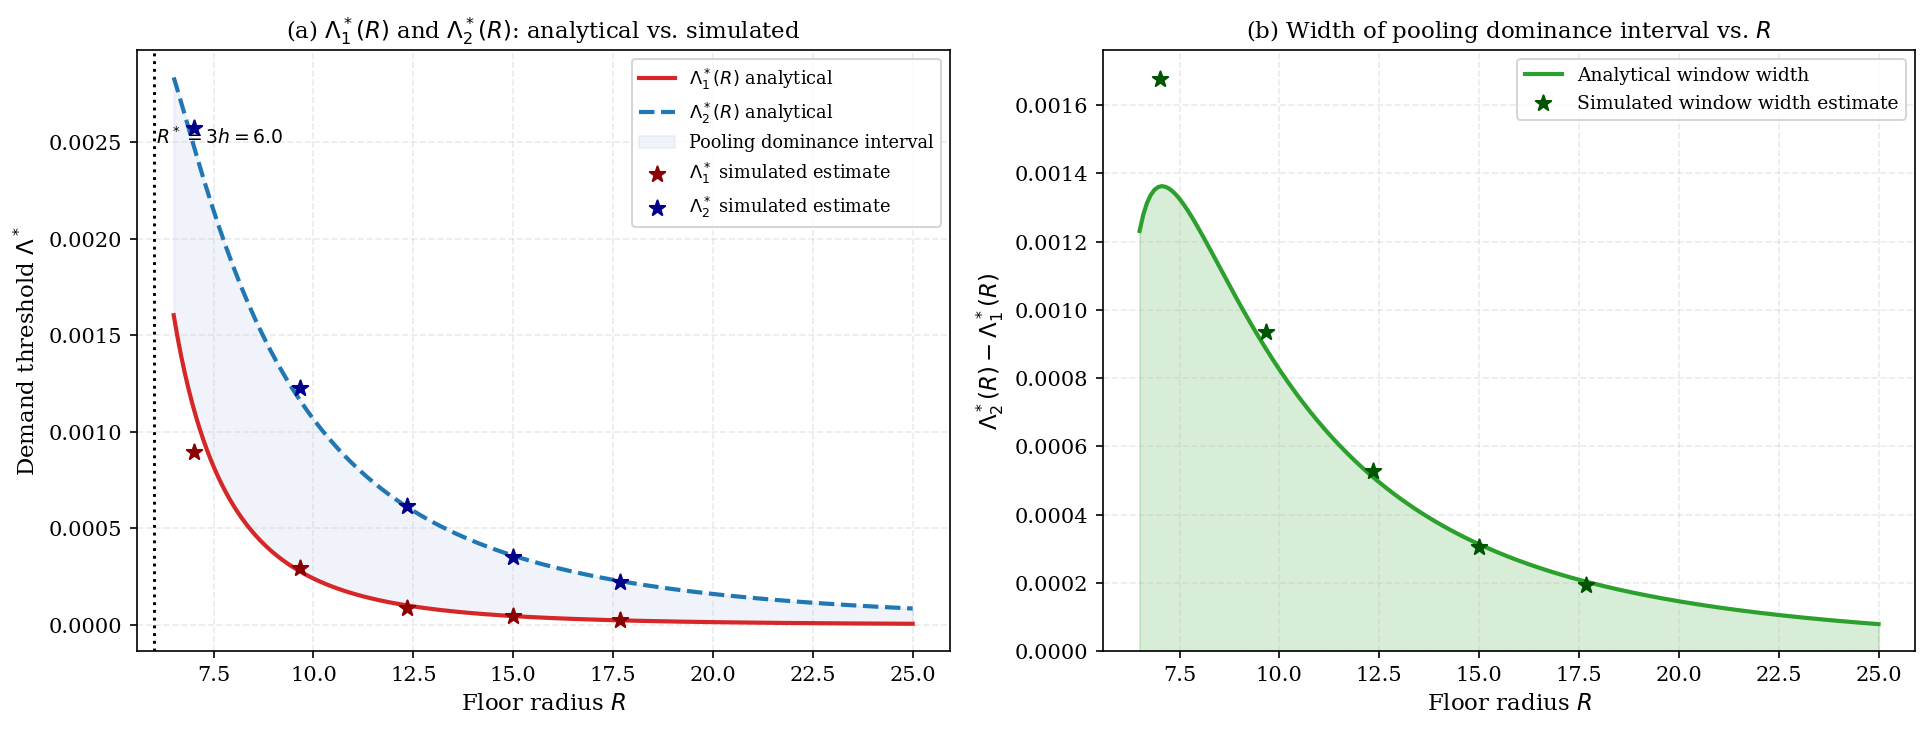

Figure 4 saved.

[5/5] Figure 5: Demand asymmetry analysis ...
  Figure 5: running simulation for 6 p₁ values × 3 regimes...


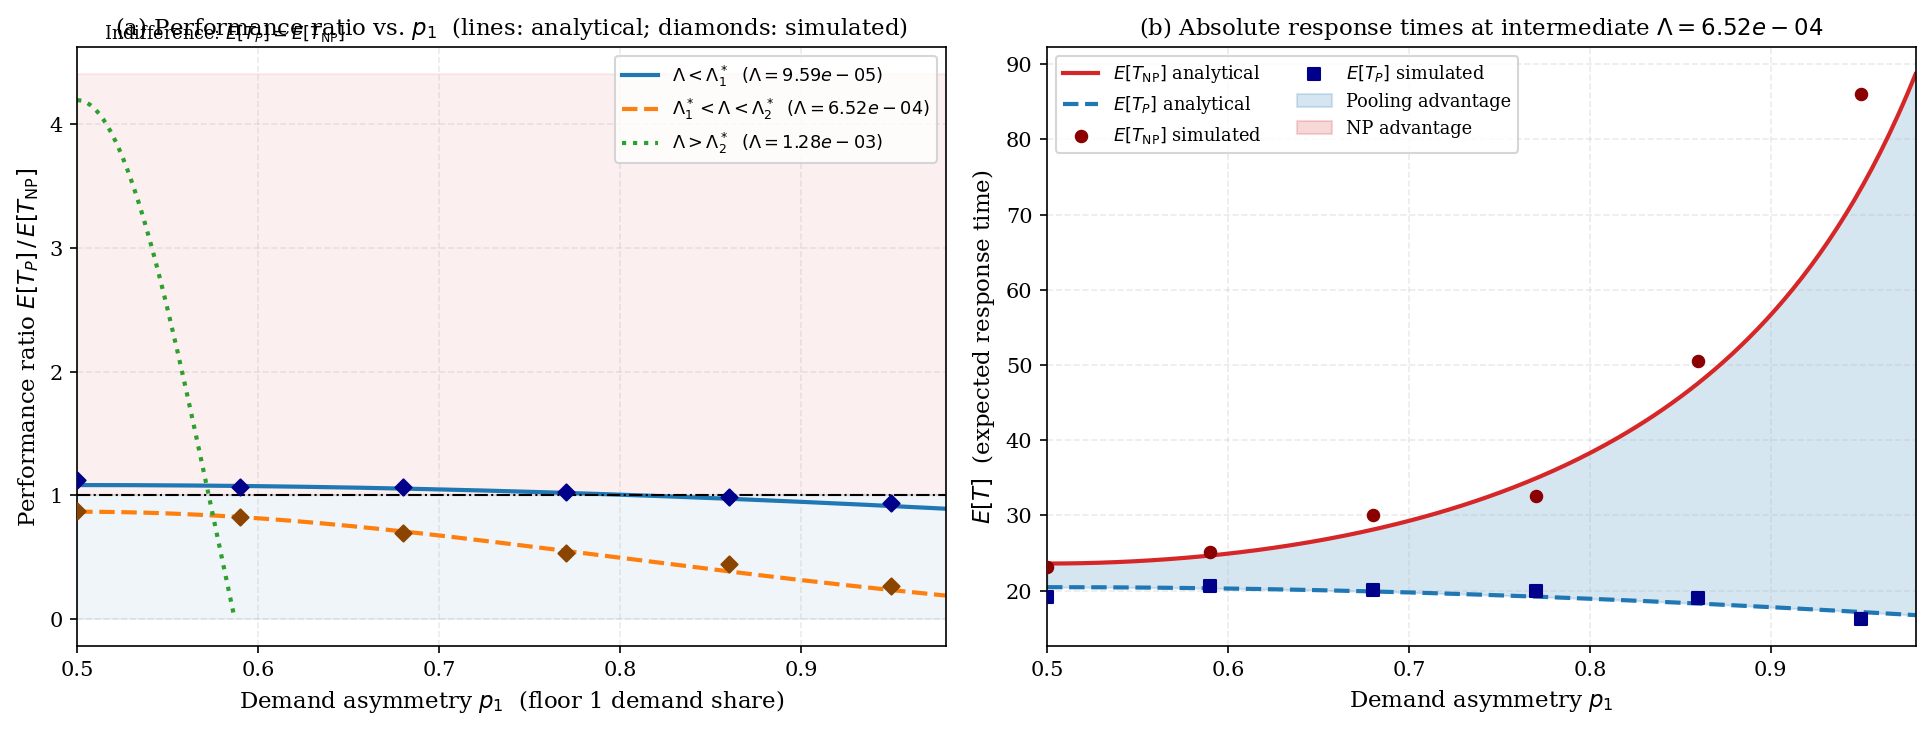

Figure 5 saved.

All 5 figures saved as PDF and PNG.


In [ ]:
# ================================================================
#  Section 3.5.2 – Sensitivity Analysis  (Option C: Sim + Theory)
#  Pooling or Segmentation? Robot Dispatch in Multi-Floor Buildings
#  Fatima Ulubayova, McMaster University
#
#  Each response-time figure overlays:
#    — Analytical curves  (solid / dashed lines)   from Section 3.4
#    — Simulated points   (scatter markers)         N=3,000 per scenario
#
#  Threshold/phase figures use analytical expressions validated by
#  simulated crossover estimates plotted as markers.
#
#  HOW TO RUN IN GOOGLE COLAB:
#    Runtime → Run all  (≈ 3–5 minutes total)
#    All figures saved as PDF and PNG in the working directory.
# ================================================================

# ── 0. Imports ──────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP  = '#D62728'   # red   — Non-Pooling analytical
C_P   = '#1F77B4'   # blue  — Pooling analytical
C_WIN = '#AEC7E8'   # light blue — pooling dominance shading
C_WID = '#2CA02C'   # green — window width

SIM_NP = '#8B0000'  # dark red  — Non-Pooling simulated
SIM_P  = '#00008B'  # dark blue — Pooling simulated


# ================================================================
#  1.  ANALYTICAL MODEL  (thesis Section 3.4)
# ================================================================

def mu_NP(R, v=1.0):
    return 3.0 * v / (4.0 * R)

def mu_P(R, h, v=1.0, p1=0.5):
    return 3.0 * v / (4.0 * R + 12.0 * p1 * (1.0 - p1) * h)

def T_NP_theory(lam, R, v=1.0, p1=0.5):
    mu = mu_NP(R, v)
    l1 = p1 * lam * R**2
    l2 = (1.0 - p1) * lam * R**2
    if l1 >= mu or l2 >= mu:
        return np.inf
    return p1 / (mu - l1) + (1.0 - p1) / (mu - l2)

def T_P_theory(lam, R, h, v=1.0, p1=0.5):
    mu  = mu_P(R, h, v, p1)
    rho = lam * R**2 / (2.0 * mu)
    if rho >= 1.0:
        return np.inf
    return 1.0 / mu + rho**2 / (mu * (1.0 - rho**2))

def thresholds_closed(R, h, v=1.0):
    """Closed-form Λ*_1, Λ*_2 (symmetric p1=0.5 only)."""
    a = mu_NP(R, v)
    b = mu_P(R, h, v, 0.5)
    disc = b * (5.0 * b - 4.0 * a)
    if disc <= 0.0:
        return None, None
    sq = np.sqrt(disc)
    x1 = (b - sq) / R**2
    x2 = (b + sq) / R**2
    if x1 <= 0.0 or x2 <= 0.0:
        return None, None
    return x1, x2

def h_max_closed(R):
    """h_max(R) = R/3  (from Proposition 3.4.X)."""
    return R / 3.0

def lim_NP(R, v=1.0, p1=0.5):
    return mu_NP(R, v) / (max(p1, 1.0 - p1) * R**2)

def lim_P(R, h, v=1.0, p1=0.5):
    return 2.0 * mu_P(R, h, v, p1) / R**2


# ================================================================
#  2.  SIMULATION ENGINE
#      Implements the Return-to-Home policy used in Section 3.5.1.
#      N=3,000 requests; first 10% discarded as warm-up.
# ================================================================

def simulate_NP(lam_total, R, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Non-Pooling: two independent M/M/1 queues (one per floor).
    Floor f receives arrivals at rate lam_f = p_f * lam_total * R^2.
    Service rate mu_NP = 3v/(4R).
    Returns demand-weighted mean response time (excluding warm-up).
    Returns np.inf if either floor is unstable.
    """
    rng = np.random.default_rng(seed)
    mu  = mu_NP(R, v)
    warmup = int(0.10 * N)

    total_rt = 0.0
    total_n  = 0

    for p_floor in [p1, 1.0 - p1]:
        lam_f = p_floor * lam_total * R**2
        if lam_f >= mu:
            return np.inf

        # Generate N inter-arrival and service times
        ia  = rng.exponential(1.0 / lam_f,  size=N)
        svc = rng.exponential(1.0 / mu,     size=N)

        arr = np.cumsum(ia)    # arrival times
        dep = np.empty(N)      # departure times

        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i - 1]) + svc[i]

        rt = dep - arr          # response times
        rt_trim = rt[warmup:]
        total_rt += p_floor * rt_trim.mean()
        total_n  += len(rt_trim)

    return total_rt   # demand-weighted average


def simulate_P(lam_total, R, h, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Pooling: one M/M/2 queue.
    Total arrival rate = lam_total * R^2.
    Service rate mu_P = 3v / (4R + 12*p1*(1-p1)*h).
    Returns mean response time (excluding warm-up).
    Returns np.inf if rho >= 1.
    """
    rng    = np.random.default_rng(seed)
    mu     = mu_P(R, h, v, p1)
    lam_q  = lam_total * R**2
    rho    = lam_q / (2.0 * mu)
    if rho >= 1.0:
        return np.inf

    warmup = int(0.10 * N)

    ia  = rng.exponential(1.0 / lam_q, size=N)
    svc = rng.exponential(1.0 / mu,    size=N)

    arr    = np.cumsum(ia)
    dep    = np.empty(N)
    server = np.zeros(2)    # completion times for the 2 servers

    for i in range(N):
        s = int(np.argmin(server))             # earliest free server
        start   = max(arr[i], server[s])
        dep[i]  = start + svc[i]
        server[s] = dep[i]

    rt      = dep - arr
    rt_trim = rt[warmup:]
    return rt_trim.mean()


def sim_curve(lam_arr, R, h, v=1.0, p1=0.5, N=3000, seed=0):
    """
    Run simulation for every Λ in lam_arr.
    Returns arrays (T_NP_sim, T_P_sim).
    """
    tnp = np.array([simulate_NP(l, R, v, p1, N, seed+j)
                    for j, l in enumerate(lam_arr)])
    tp  = np.array([simulate_P(l, R, h, v, p1, N, seed+1000+j)
                    for j, l in enumerate(lam_arr)])
    return tnp, tp


def theory_curve(lam_arr, R, h, v=1.0, p1=0.5):
    """Analytical curves for every Λ in lam_arr."""
    tnp = np.array([T_NP_theory(l, R, v, p1) for l in lam_arr])
    tp  = np.array([T_P_theory(l, R, h, v, p1) for l in lam_arr])
    tnp[np.isinf(tnp)] = np.nan
    tp[np.isinf(tp)]   = np.nan
    return tnp, tp


def find_sim_crossings(lam_arr, T_NP_sim, T_P_sim):
    """
    Estimate simulated crossover points (Λ*_1 and Λ*_2) by linear
    interpolation of the sign of (T_P_sim - T_NP_sim).
    Returns list of crossover Λ values.
    """
    d = T_P_sim - T_NP_sim
    crossings = []
    for i in range(len(d) - 1):
        if np.isnan(d[i]) or np.isnan(d[i + 1]):
            continue
        if d[i] * d[i + 1] < 0:
            # Linear interpolation
            frac = -d[i] / (d[i + 1] - d[i])
            crossings.append(lam_arr[i] + frac * (lam_arr[i + 1] - lam_arr[i]))
    return crossings


# ================================================================
#  3. FIGURE 1
#     2×2 response-time curves: analytical + simulated overlay.
#     Four h values: 0, ~1.5, ~2.5, ~h_max.
# ================================================================

def figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25):

    p1  = 0.5
    hm  = h_max_closed(R)
    h_vals = [0.0, hm * 0.45, hm * 0.75, hm * 0.95]
    labels = [
        r'$h = 0$ (no vertical cost)',
        rf'$h = {hm*0.45:.2f}$  (wide pooling window)',
        rf'$h = {hm*0.75:.2f}$  (narrow pooling window)',
        rf'$h = {hm*0.95:.2f} \approx h_{{\max}}(R)$  (window collapses)',
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, h, label in zip(axes, h_vals, labels):

        lim = 0.90 * min(lim_NP(R, v, p1), lim_P(R, h, v, p1))
        lam_dense = np.linspace(1e-9, lim, 400)
        lam_sim   = np.linspace(1e-9, lim, N_LAM)

        # Analytical
        tnp_th, tp_th = theory_curve(lam_dense, R, h, v, p1)

        # Simulated
        tnp_s, tp_s = sim_curve(lam_sim, R, h, v, p1, N=N_SIM)
        tnp_s[np.isinf(tnp_s)] = np.nan
        tp_s[np.isinf(tp_s)]   = np.nan

        # y ceiling from analytical
        all_fin = np.concatenate([tnp_th[~np.isnan(tnp_th)],
                                   tp_th[~np.isnan(tp_th)]])
        y_ceil  = np.percentile(all_fin, 94) * 1.6 if len(all_fin) > 0 else 100.

        # Dominance shading (from analytical)
        valid  = ~(np.isnan(tnp_th) | np.isnan(tp_th))
        p_wins = valid & (tp_th < tnp_th)
        ax.fill_between(lam_dense, 0, y_ceil, where=p_wins,
                        alpha=0.12, color=C_P)
        ax.fill_between(lam_dense, 0, y_ceil, where=~p_wins & valid,
                        alpha=0.12, color=C_NP)

        # Analytical curves
        ax.plot(lam_dense, np.clip(tnp_th, 0, y_ceil),
                color=C_NP, lw=2.0, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}]$ analytical')
        ax.plot(lam_dense, np.clip(tp_th, 0, y_ceil),
                color=C_P, lw=2.0, linestyle='--',
                label=r'$E[T_P]$ analytical')

        # Simulated scatter
        mask = ~np.isnan(tnp_s)
        ax.scatter(lam_sim[mask], np.clip(tnp_s[mask], 0, y_ceil),
                   color=SIM_NP, s=18, zorder=5, marker='o',
                   label=r'$E[T_{\mathrm{NP}}]$ simulated')
        mask = ~np.isnan(tp_s)
        ax.scatter(lam_sim[mask], np.clip(tp_s[mask], 0, y_ceil),
                   color=SIM_P, s=18, zorder=5, marker='s',
                   label=r'$E[T_P]$ simulated')

        # Threshold markers (analytical)
        L1, L2 = thresholds_closed(R, h, v)
        for L, sym in [(L1, r'$\Lambda_1^*$'), (L2, r'$\Lambda_2^*$')]:
            if L is not None and 0 < L < lim:
                ax.axvline(L, color='black', linestyle=':', lw=1.3)
                ax.text(L, y_ceil * 0.87, sym, ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.75,
                                  edgecolor='none', pad=1.5))

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y_ceil)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$')
        ax.set_title(label, fontsize=10)
        ax.legend(loc='upper left', fontsize=8, ncol=2)

    # fig.suptitle(
    #     r'Figure 3.X: Expected Response Time — Analytical Curves and Simulated Points'
    #     '\n'
    #     r'$R=10,\ v=1,\ p_1=0.5,\ N=3{,}000$ per scenario  '
    #     r'(10\% warm-up).  Blue shading: Pooling dominates.',
    #     fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig('fig1_response_time_curves.pdf', bbox_inches='tight')
    plt.savefig('fig1_response_time_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 1 saved.')


# ================================================================
#  4. FIGURE 2
#     Λ*₁(h), Λ*₂(h) — analytical curves plus simulated crossover
#     estimates for 7 h values (marked as ★ on the figure).
# ================================================================

def figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=35, n_h_val=200,
            n_h_sim=7):

    p1 = 0.5
    hm = h_max_closed(R)

    # Analytical threshold curves
    h_arr  = np.linspace(0.02, hm * 0.9999, n_h_val)
    L1_th  = np.array([thresholds_closed(R, h, v)[0] for h in h_arr],
                       dtype=float)
    L2_th  = np.array([thresholds_closed(R, h, v)[1] for h in h_arr],
                       dtype=float)
    W_th   = L2_th - L1_th

    # Simulated crossover estimates at n_h_sim h values.
    # We start at hm*0.35 (not hm*0.15) because at very small h the lower
    # threshold Lambda*_1 lies within ~2 grid steps of zero, making it
    # indistinguishable from simulation noise.  At hm*0.35 and above,
    # Lambda*_1 sits at least 4 grid steps from zero and is reliably detected.
    h_sim_vals = np.linspace(hm * 0.35, hm * 0.90, n_h_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 2: running simulation for {n_h_sim} h values...')
    for h_s in h_sim_vals:
        lim = 0.88 * min(lim_NP(R, v, p1), lim_P(R, h_s, v, p1))
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R, h_s, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: threshold curves ───────────────────────────────────
    ax1.plot(h_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(h)$ analytical')
    ax1.plot(h_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(h)$ analytical')
    ax1.fill_between(h_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')

    # Simulated crossovers
    valid = ~np.isnan(L1_sim_est)
    ax1.scatter(h_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(h_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')

    ax1.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax1.text(hm * 0.97, float(np.nanmax(L2_th)) * 0.90,
             rf'$h_{{\max}}(R) = R/3 = {hm:.2f}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax1.set_xlabel(r'Vertical travel penalty $h$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(h)$ and $\Lambda_2^*(h)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5, loc='upper left')

    # ── Right: window width ──────────────────────────────────────
    ax2.plot(h_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(h_arr, 0, W_th, alpha=0.18, color=C_WID)

    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(h_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')

    ax2.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax2.text(hm * 0.97, float(np.nanmax(W_th)) * 0.88,
             r'Window collapses at $h_{\max}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax2.set_xlabel(r'Vertical travel penalty $h$')
    ax2.set_ylabel(r'$\Lambda_2^*(h) - \Lambda_1^*(h)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $h$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    # fig.suptitle(
    #     rf'Figure 3.Y: Sensitivity of Thresholds to Vertical Penalty $h$'
    #     '\n'
    #     rf'$R={R},\ v={v},\ p_1=0.5$.  '
    #     r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig2_threshold_vs_h.pdf', bbox_inches='tight')
    plt.savefig('fig2_threshold_vs_h.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 2 saved.')


# ================================================================
#  5. FIGURE 3
#     Phase diagram: performance ratio E[T_P]/E[T_NP] in (Λ, h).
#     Analytical. Closed-form threshold curves overlaid.
#     (Too many grid points for full simulation; validated by Figs 1–2.)
# ================================================================

def figure3(R=10.0, v=1.0, n_lam=250, n_h=200):

    p1     = 0.5
    hm     = h_max_closed(R)
    lim_np = lim_NP(R, v, p1) * 0.995

    lam_arr = np.linspace(1e-9, lim_np, n_lam)
    h_arr   = np.linspace(0.02, hm * 1.35, n_h)

    ratio_grid = np.full((n_h, n_lam), np.nan)

    for i, h in enumerate(h_arr):
        lp = lim_P(R, h, v, p1) * 0.995
        for j, lam in enumerate(lam_arr):
            tnp = T_NP_theory(lam, R, v, p1)
            tp  = T_P_theory(lam, R, h, v, p1)
            if np.isinf(tnp):
                ratio_grid[i, j] = np.nan
            elif np.isinf(tp):
                ratio_grid[i, j] = np.inf
            else:
                ratio_grid[i, j] = tp / tnp

    plot_grid = np.where(np.isinf(ratio_grid), np.nan,
                         np.clip(ratio_grid, 0.4, 3.0))
    unstable  = np.isinf(ratio_grid)

    fig, ax = plt.subplots(figsize=(10, 6))

    norm = mcolors.TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=3.0)
    im   = ax.pcolormesh(lam_arr, h_arr, plot_grid,
                         cmap='RdYlBu_r', norm=norm, shading='auto')
    ax.pcolormesh(lam_arr, h_arr,
                  np.where(unstable, 1.0, np.nan),
                  cmap='Greys', vmin=0, vmax=1.5,
                  alpha=0.55, shading='auto')

    # Overlay analytical threshold curves
    h_line  = np.linspace(0.02, hm, 400)
    L1_line = np.array([thresholds_closed(R, h, v)[0] for h in h_line],
                        dtype=float)
    L2_line = np.array([thresholds_closed(R, h, v)[1] for h in h_line],
                        dtype=float)
    ax.plot(L1_line, h_line, 'k-',  lw=2.2, label=r'$\Lambda_1^*(h)$')
    ax.plot(L2_line, h_line, 'k--', lw=2.2, label=r'$\Lambda_2^*(h)$')
    ax.axhline(hm, color='black', linestyle=':', lw=1.5)
    ax.text(lim_np * 0.04, hm * 1.02,
            rf'$h_{{\max}} = R/3 = {hm:.2f}$', fontsize=9, va='bottom')

    cbar = fig.colorbar(im, ax=ax, extend='both', fraction=0.03, pad=0.02)
    cbar.set_label(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    cbar.ax.axhline(1.0, color='black', lw=1.5)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.set_xlabel(r'Demand rate $\Lambda$')
    ax.set_ylabel(r'Vertical travel penalty $h$')
    # ax.set_title(
    #     r'Figure 3.Z: Phase Diagram in $(\Lambda,\,h)$ Space  '
    #     r'(analytical, validated in Figures 3.X–3.Y)'
    #     '\n'
    #     r'Blue: Pooling dominates  ·  Red: NP dominates  ·  '
    #     r'Grey: Pooling unstable'
    #     '\n'
    #     rf'$R={R},\ v={v},\ p_1=0.5$',
    #     fontsize=10)
    plt.tight_layout()
    plt.savefig('fig3_phase_diagram.pdf', bbox_inches='tight')
    plt.savefig('fig3_phase_diagram.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 3 saved.')


# ================================================================
#  6. FIGURE 4
#     Λ*₁(R), Λ*₂(R) — analytical curves plus simulated crossover
#     estimates for 7 R values.
# ================================================================

def figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35,
            n_R_val=200, n_R_sim=7):

    p1    = 0.5
    R_arr = np.linspace(3.0 * h + 0.5, 25.0, n_R_val)

    L1_th = np.array([thresholds_closed(R, h, v)[0] for R in R_arr],
                      dtype=float)
    L2_th = np.array([thresholds_closed(R, h, v)[1] for R in R_arr],
                      dtype=float)
    W_th  = L2_th - L1_th

    # Simulated crossover estimates
    R_sim_vals = np.linspace(3.0 * h + 1.0, 23.0, n_R_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 4: running simulation for {n_R_sim} R values...')
    for R_s in R_sim_vals:
        lim = 0.88 * min(lim_NP(R_s, v, p1), lim_P(R_s, h, v, p1))
        if lim <= 0:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)
            continue
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R_s, h, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)
    valid      = ~np.isnan(L1_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left ─────────────────────────────────────────────────────
    ax1.plot(R_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(R)$ analytical')
    ax1.plot(R_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(R)$ analytical')
    ax1.fill_between(R_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')
    ax1.scatter(R_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(R_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')
    R_star = 3.0 * h
    ax1.axvline(R_star, color='black', linestyle=':', lw=1.4)
    ax1.text(R_star * 1.01, float(np.nanmax(L2_th)) * 0.88,
             rf'$R^* = 3h = {R_star:.1f}$', fontsize=9)
    ax1.set_xlabel(r'Floor radius $R$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(R)$ and $\Lambda_2^*(R)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5)

    # ── Right ────────────────────────────────────────────────────
    ax2.plot(R_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(R_arr, 0, W_th, alpha=0.18, color=C_WID)
    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(R_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')
    ax2.set_xlabel(r'Floor radius $R$')
    ax2.set_ylabel(r'$\Lambda_2^*(R) - \Lambda_1^*(R)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $R$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    # fig.suptitle(
    #     rf'Figure 3.W: Sensitivity of Thresholds to Floor Radius $R$'
    #     '\n'
    #     rf'$h={h},\ v={v},\ p_1=0.5$.  '
    #     r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig4_threshold_vs_R.pdf', bbox_inches='tight')
    plt.savefig('fig4_threshold_vs_R.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 4 saved.')


# ================================================================
#  7. FIGURE 5
#     Demand asymmetry: performance ratio and absolute response
#     times vs. p₁, with simulated overlay.
# ================================================================

def figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6):

    # Symmetric thresholds for regime selection
    L1_s, L2_s = thresholds_closed(R, h, v)
    if L1_s is None or L2_s is None:
        print(f'No thresholds: need h < R/3 = {R/3:.2f}.')
        return

    lam_regimes = {
        rf'$\Lambda < \Lambda_1^*$  '
        rf'$(\Lambda={L1_s*0.40:.2e})$': L1_s * 0.40,

        rf'$\Lambda_1^* < \Lambda < \Lambda_2^*$  '
        rf'$(\Lambda={0.5*(L1_s+L2_s):.2e})$': 0.5 * (L1_s + L2_s),

        rf'$\Lambda > \Lambda_2^*$  '
        rf'$(\Lambda={L2_s*1.20:.2e})$': L2_s * 1.20,
    }

    p1_th  = np.linspace(0.50, 0.98, 200)   # dense for analytical
    p1_sim = np.linspace(0.50, 0.95, n_p)   # coarse for simulation

    styles = ['-', '--', ':']
    cols   = ['#1F77B4', '#FF7F0E', '#2CA02C']
    scols  = ['#00008B', '#8B4500', '#004400']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: performance ratio vs p₁ ───────────────────────────
    print(f'  Figure 5: running simulation for {n_p} p₁ values × 3 regimes...')
    for (label, lam), ls, col, scol in zip(
            lam_regimes.items(), styles, cols, scols):

        # Analytical ratio
        ratios_th = []
        for p in p1_th:
            lnp = lim_NP(R, v, p)
            lp  = lim_P(R, h, v, p)
            if lam >= min(lnp, lp):
                ratios_th.append(np.nan)
                continue
            tnp = T_NP_theory(lam, R, v, p)
            tp  = T_P_theory(lam, R, h, v, p)
            ratios_th.append(tp / tnp if not (np.isinf(tnp) or np.isinf(tp))
                             else np.nan)
        ax1.plot(p1_th, ratios_th, lw=2, linestyle=ls, color=col,
                 label=label)

        # Simulated ratio
        ratios_sim = []
        for p in p1_sim:
            lnp = lim_NP(R, v, p)
            lp  = lim_P(R, h, v, p)
            if lam >= min(lnp, lp) * 0.90:
                ratios_sim.append(np.nan)
                continue
            tnp_s = simulate_NP(lam, R, v, p, N=N_SIM)
            tp_s  = simulate_P(lam, R, h, v, p, N=N_SIM)
            ratios_sim.append(tp_s / tnp_s
                              if not (np.isinf(tnp_s) or np.isinf(tp_s))
                              else np.nan)
        ratios_sim = np.array(ratios_sim)
        valid = ~np.isnan(ratios_sim)
        ax1.scatter(p1_sim[valid], ratios_sim[valid],
                    color=scol, s=30, zorder=5, marker='D')

    ax1.axhline(1.0, color='black', lw=1.0, linestyle='-.')
    ax1.text(0.515, 1.015,
             r'Indifference: $E[T_P] = E[T_{\mathrm{NP}}]$',
             fontsize=8.5, transform=ax1.get_xaxis_transform())
    y1_lo, y1_hi = ax1.get_ylim()
    ax1.fill_between([0.5, 0.98], 0.0, 1.0, alpha=0.07, color=C_P)
    ax1.fill_between([0.5, 0.98], 1.0, max(y1_hi, 2.0),
                     alpha=0.07, color=C_NP)
    ax1.set_xlim(0.5, 0.98)
    ax1.set_xlabel(r'Demand asymmetry $p_1$  (floor 1 demand share)')
    ax1.set_ylabel(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    ax1.set_title(
        r'(a) Performance ratio vs. $p_1$  '
        r'(lines: analytical; diamonds: simulated)')
    ax1.legend(fontsize=8.5, loc='upper right')

    # ── Right: absolute response times at intermediate Λ ────────
    lam_mid = 0.5 * (L1_s + L2_s)
    tnp_th_v, tp_th_v = [], []
    tnp_sim_v, tp_sim_v = [], []

    for p in p1_th:
        lnp = lim_NP(R, v, p); lp = lim_P(R, h, v, p)
        if lam_mid >= min(lnp, lp):
            tnp_th_v.append(np.nan); tp_th_v.append(np.nan)
        else:
            tnp_th_v.append(T_NP_theory(lam_mid, R, v, p))
            tp_th_v.append(T_P_theory(lam_mid, R, h, v, p))

    for p in p1_sim:
        lnp = lim_NP(R, v, p); lp = lim_P(R, h, v, p)
        if lam_mid >= min(lnp, lp) * 0.90:
            tnp_sim_v.append(np.nan); tp_sim_v.append(np.nan)
        else:
            tnp_sim_v.append(simulate_NP(lam_mid, R, v, p, N=N_SIM))
            tp_sim_v.append(simulate_P(lam_mid, R, h, v, p, N=N_SIM))

    tnp_th_v = np.array(tnp_th_v)
    tp_th_v  = np.array(tp_th_v)
    tnp_sim_v = np.array(tnp_sim_v, dtype=float)
    tp_sim_v  = np.array(tp_sim_v,  dtype=float)
    tnp_th_v[np.isinf(tnp_th_v)] = np.nan
    tp_th_v[np.isinf(tp_th_v)]   = np.nan
    tnp_sim_v[np.isinf(tnp_sim_v)] = np.nan
    tp_sim_v[np.isinf(tp_sim_v)]   = np.nan

    ax2.plot(p1_th, tnp_th_v, color=C_NP, lw=2,
             label=r'$E[T_{\mathrm{NP}}]$ analytical')
    ax2.plot(p1_th, tp_th_v,  color=C_P,  lw=2, linestyle='--',
             label=r'$E[T_P]$ analytical')

    v_np = ~np.isnan(tnp_sim_v)
    v_p  = ~np.isnan(tp_sim_v)
    ax2.scatter(p1_sim[v_np], tnp_sim_v[v_np],
                color=SIM_NP, s=30, zorder=5, marker='o',
                label=r'$E[T_{\mathrm{NP}}]$ simulated')
    ax2.scatter(p1_sim[v_p], tp_sim_v[v_p],
                color=SIM_P, s=30, zorder=5, marker='s',
                label=r'$E[T_P]$ simulated')

    # Shade advantage region
    p_adv = tp_th_v < tnp_th_v
    ax2.fill_between(p1_th, tp_th_v, tnp_th_v,
                     where= p_adv, alpha=0.18, color=C_P,
                     label='Pooling advantage')
    ax2.fill_between(p1_th, tp_th_v, tnp_th_v,
                     where=~p_adv, alpha=0.18, color=C_NP,
                     label='NP advantage')

    ax2.set_xlim(0.5, 0.98)
    ax2.set_xlabel(r'Demand asymmetry $p_1$')
    ax2.set_ylabel(r'$E[T]$  (expected response time)')
    ax2.set_title(
        rf'(b) Absolute response times at intermediate '
        rf'$\Lambda = {lam_mid:.2e}$')
    ax2.legend(fontsize=8.5, ncol=2)

    # fig.suptitle(
    #     r'Figure 3.V: Sensitivity to Demand Asymmetry $p_1$'
    #     '\n'
    #     rf'$R={R},\ h={h},\ v={v}$.  '
    #     r'Lines: analytical.  Markers: simulated ($N=3{,}000$).',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig5_demand_asymmetry.pdf', bbox_inches='tight')
    plt.savefig('fig5_demand_asymmetry.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 5 saved.')


# ================================================================
#  8. RUN ALL FIGURES
# ================================================================

if __name__ == '__main__':

    print('=' * 65)
    print('Section 3.5.2  Sensitivity Analysis  (Option C)')
    print('Analytical curves  +  Simulated points  (N=3,000 per run)')
    print(f'Analytical result: h_max(R=10) = R/3 = {h_max_closed(10):.4f}')
    print('=' * 65)

    print('\n[1/5] Figure 1: Response-time curves for four h values ...')
    figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25)

    print('\n[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...')
    figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=50, n_h_sim=7)

    print('\n[3/5] Figure 3: Phase diagram in (Lambda, h) space ...')
    figure3(R=10.0, v=1.0)

    print('\n[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...')
    figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35, n_R_sim=7)

    print('\n[5/5] Figure 5: Demand asymmetry analysis ...')
    figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6)

    print('\nAll 5 figures saved as PDF and PNG.')


Section 3.5.2  Sensitivity Analysis  (Option C)
Analytical curves  +  Simulated points  (N=3,000 per run)
Analytical result: h_max(R=10) = R/3 = 3.3333

[1/5] Figure 1: Response-time curves for four h values ...


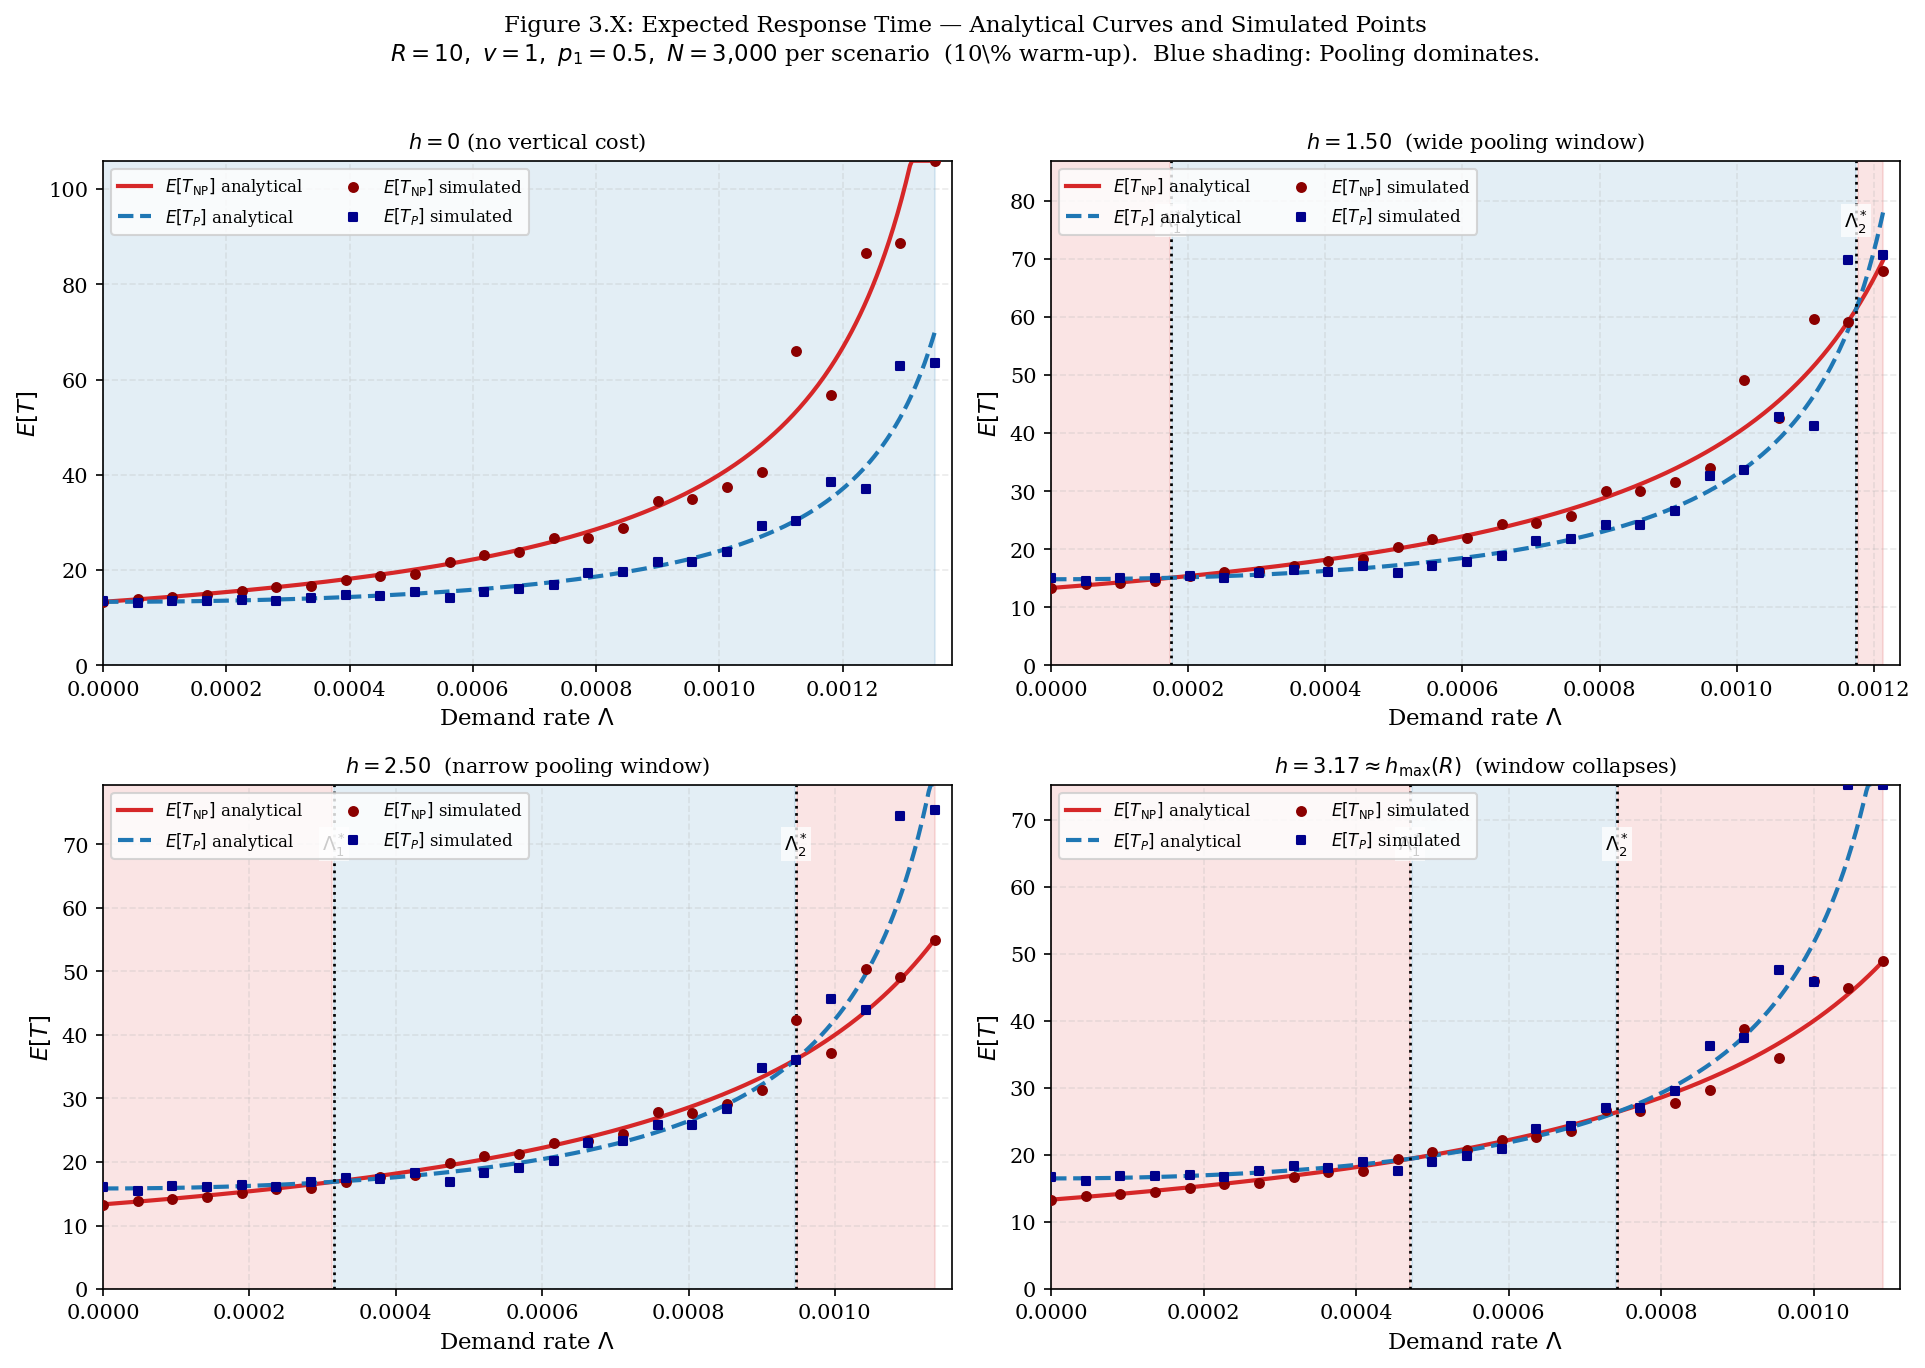

Figure 1 saved.

[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...
  Figure 2: running simulation for 7 h values...


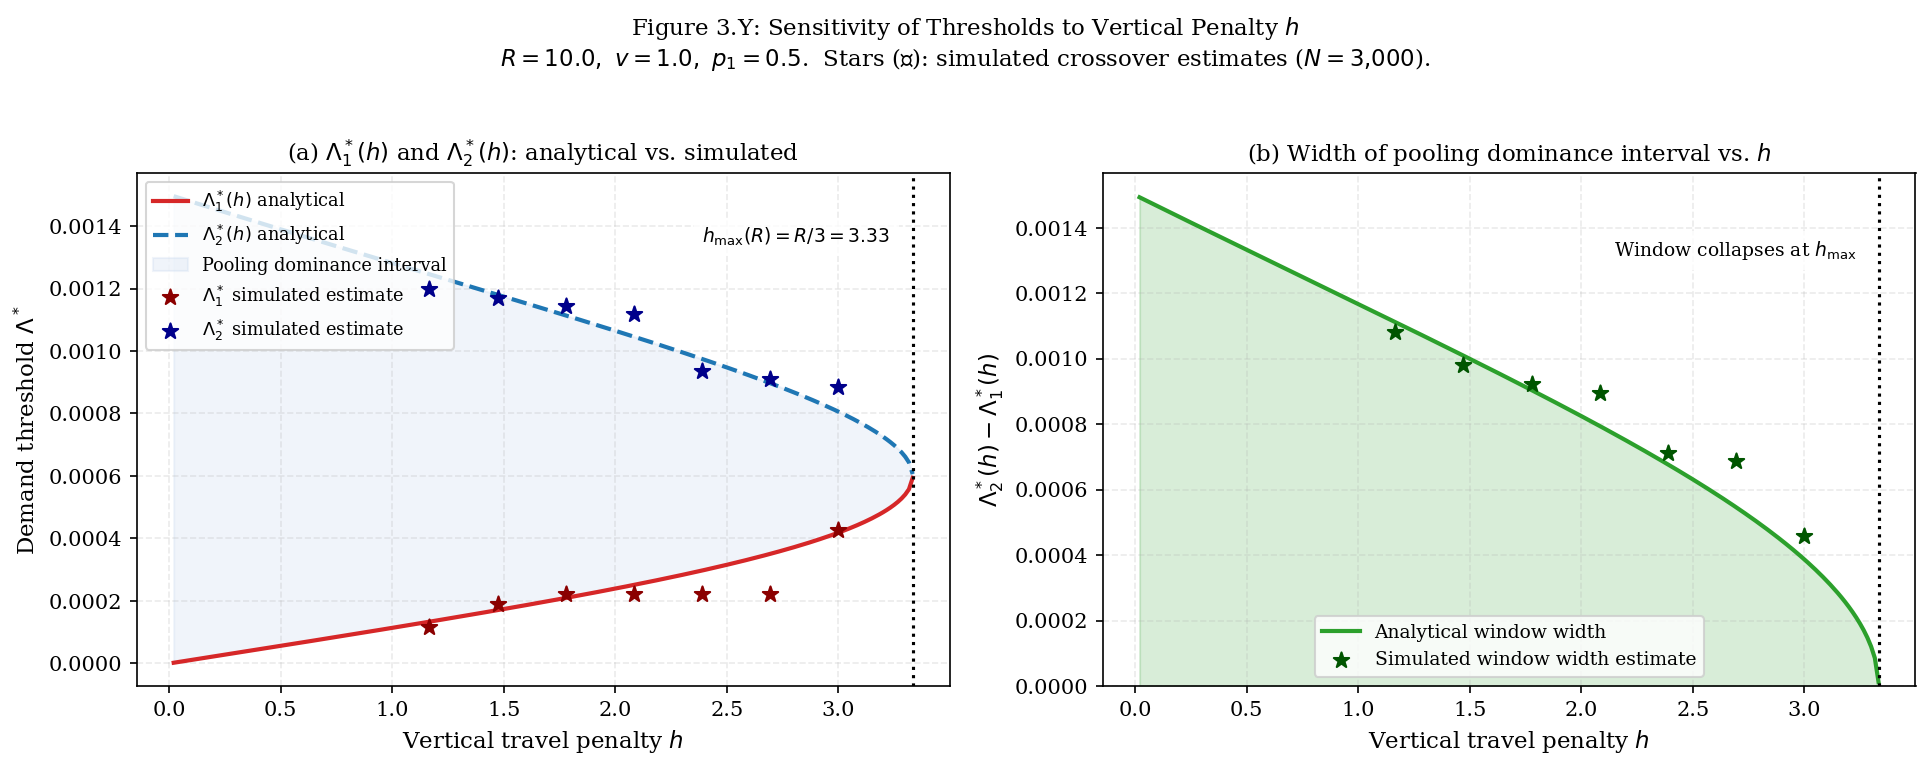

Figure 2 saved.

[3/5] Figure 3: Phase diagram in (Lambda, h) space ...


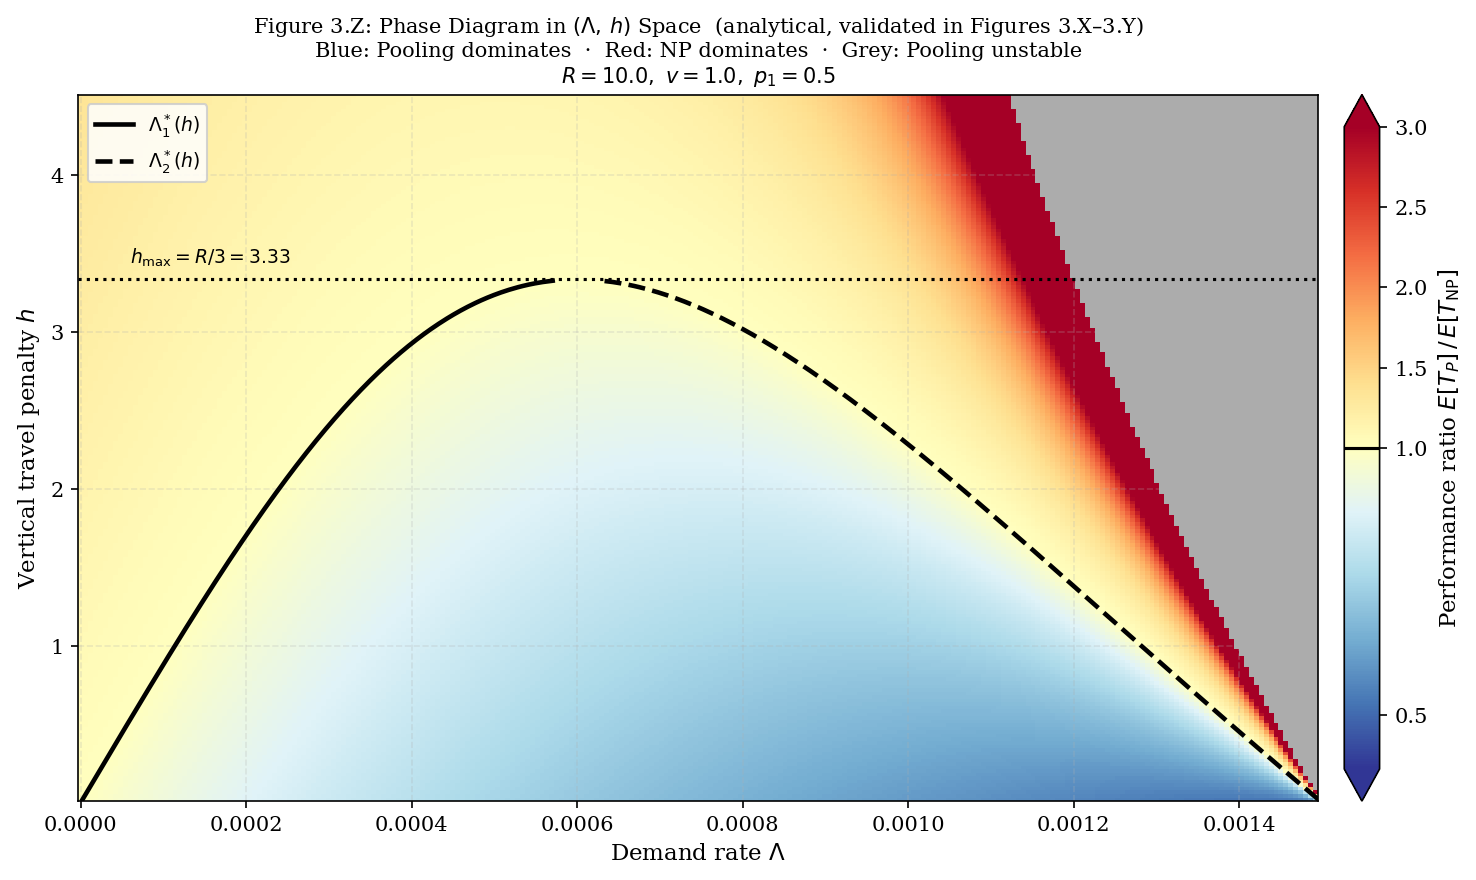

Figure 3 saved.

[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...
  Figure 4: running simulation for 7 R values...


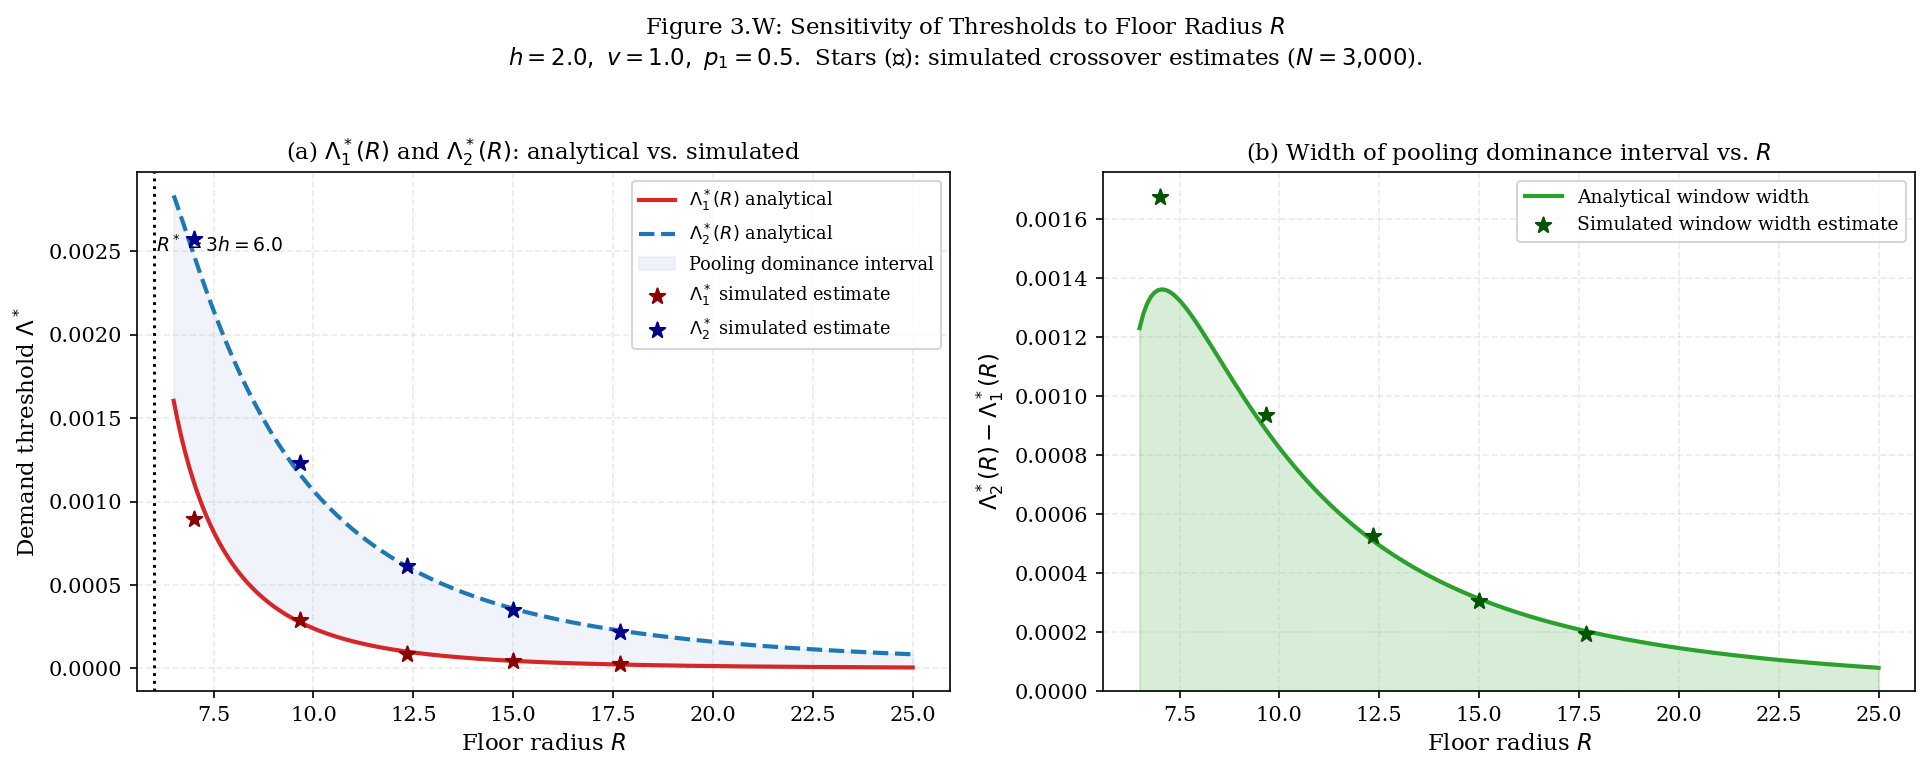

Figure 4 saved.

[5/5] Figure 5: Demand asymmetry analysis ...
  Figure 5: running simulation for 6 p1 values x 3 regimes...


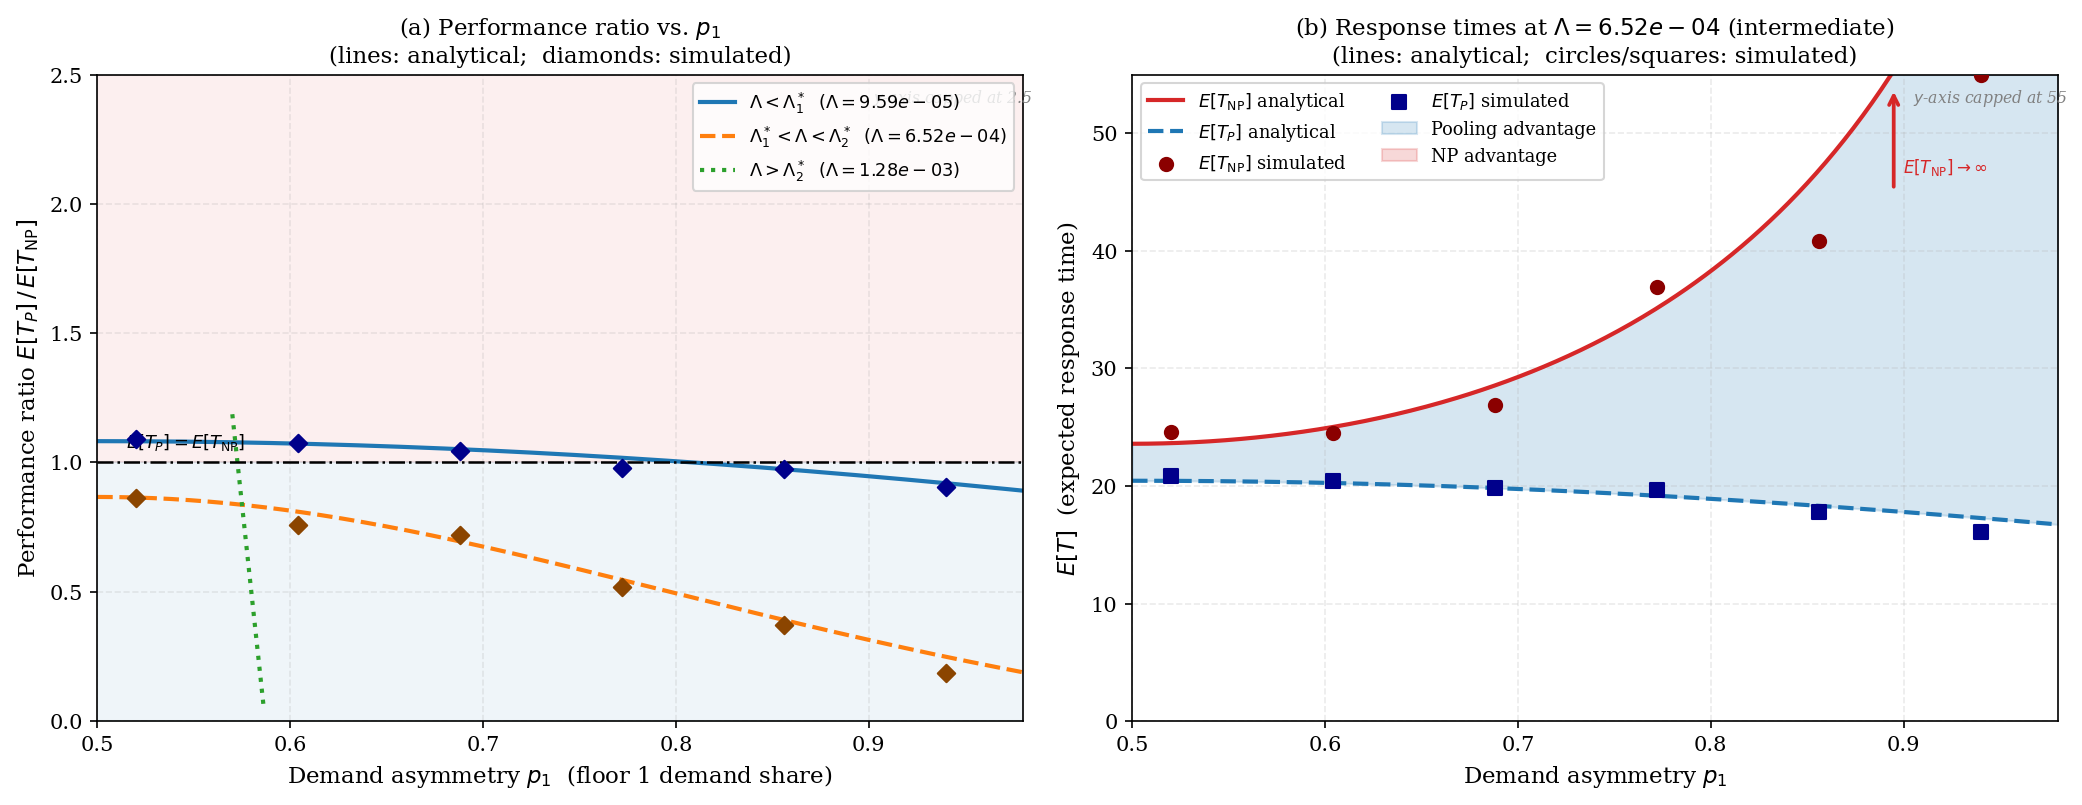

Figure 5 saved.

All 5 figures saved as PDF and PNG.


In [ ]:
# ================================================================
#  Section 3.5.2 – Sensitivity Analysis  (Option C: Sim + Theory)
#  Pooling or Segmentation? Robot Dispatch in Multi-Floor Buildings
#  Fatima Ulubayova, McMaster University
#
#  Each response-time figure overlays:
#    — Analytical curves  (solid / dashed lines)   from Section 3.4
#    — Simulated points   (scatter markers)         N=3,000 per scenario
#
#  Threshold/phase figures use analytical expressions validated by
#  simulated crossover estimates plotted as markers.
#
#  HOW TO RUN IN GOOGLE COLAB:
#    Runtime → Run all  (≈ 3–5 minutes total)
#    All figures saved as PDF and PNG in the working directory.
# ================================================================

# ── 0. Imports ──────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP  = '#D62728'   # red   — Non-Pooling analytical
C_P   = '#1F77B4'   # blue  — Pooling analytical
C_WIN = '#AEC7E8'   # light blue — pooling dominance shading
C_WID = '#2CA02C'   # green — window width

SIM_NP = '#8B0000'  # dark red  — Non-Pooling simulated
SIM_P  = '#00008B'  # dark blue — Pooling simulated


# ================================================================
#  1.  ANALYTICAL MODEL  (thesis Section 3.4)
# ================================================================

def mu_NP(R, v=1.0):
    return 3.0 * v / (4.0 * R)

def mu_P(R, h, v=1.0, p1=0.5):
    return 3.0 * v / (4.0 * R + 12.0 * p1 * (1.0 - p1) * h)

def T_NP_theory(lam, R, v=1.0, p1=0.5):
    mu = mu_NP(R, v)
    l1 = p1 * lam * R**2
    l2 = (1.0 - p1) * lam * R**2
    if l1 >= mu or l2 >= mu:
        return np.inf
    return p1 / (mu - l1) + (1.0 - p1) / (mu - l2)

def T_P_theory(lam, R, h, v=1.0, p1=0.5):
    mu  = mu_P(R, h, v, p1)
    rho = lam * R**2 / (2.0 * mu)
    if rho >= 1.0:
        return np.inf
    return 1.0 / mu + rho**2 / (mu * (1.0 - rho**2))

def thresholds_closed(R, h, v=1.0):
    """Closed-form Λ*_1, Λ*_2 (symmetric p1=0.5 only)."""
    a = mu_NP(R, v)
    b = mu_P(R, h, v, 0.5)
    disc = b * (5.0 * b - 4.0 * a)
    if disc <= 0.0:
        return None, None
    sq = np.sqrt(disc)
    x1 = (b - sq) / R**2
    x2 = (b + sq) / R**2
    if x1 <= 0.0 or x2 <= 0.0:
        return None, None
    return x1, x2

def h_max_closed(R):
    """h_max(R) = R/3  (from Proposition 3.4.X)."""
    return R / 3.0

def lim_NP(R, v=1.0, p1=0.5):
    return mu_NP(R, v) / (max(p1, 1.0 - p1) * R**2)

def lim_P(R, h, v=1.0, p1=0.5):
    return 2.0 * mu_P(R, h, v, p1) / R**2


# ================================================================
#  2.  SIMULATION ENGINE
#      Implements the Return-to-Home policy used in Section 3.5.1.
#      N=3,000 requests; first 10% discarded as warm-up.
# ================================================================

def simulate_NP(lam_total, R, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Non-Pooling: two independent M/M/1 queues (one per floor).
    Floor f receives arrivals at rate lam_f = p_f * lam_total * R^2.
    Service rate mu_NP = 3v/(4R).
    Returns demand-weighted mean response time (excluding warm-up).
    Returns np.inf if either floor is unstable.
    """
    rng = np.random.default_rng(seed)
    mu  = mu_NP(R, v)
    warmup = int(0.10 * N)

    total_rt = 0.0
    total_n  = 0

    for p_floor in [p1, 1.0 - p1]:
        lam_f = p_floor * lam_total * R**2
        if lam_f >= mu:
            return np.inf

        # Generate N inter-arrival and service times
        ia  = rng.exponential(1.0 / lam_f,  size=N)
        svc = rng.exponential(1.0 / mu,     size=N)

        arr = np.cumsum(ia)    # arrival times
        dep = np.empty(N)      # departure times

        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i - 1]) + svc[i]

        rt = dep - arr          # response times
        rt_trim = rt[warmup:]
        total_rt += p_floor * rt_trim.mean()
        total_n  += len(rt_trim)

    return total_rt   # demand-weighted average


def simulate_P(lam_total, R, h, v=1.0, p1=0.5, N=3000, seed=None):
    """
    Pooling: one M/M/2 queue.
    Total arrival rate = lam_total * R^2.
    Service rate mu_P = 3v / (4R + 12*p1*(1-p1)*h).
    Returns mean response time (excluding warm-up).
    Returns np.inf if rho >= 1.
    """
    rng    = np.random.default_rng(seed)
    mu     = mu_P(R, h, v, p1)
    lam_q  = lam_total * R**2
    rho    = lam_q / (2.0 * mu)
    if rho >= 1.0:
        return np.inf

    warmup = int(0.10 * N)

    ia  = rng.exponential(1.0 / lam_q, size=N)
    svc = rng.exponential(1.0 / mu,    size=N)

    arr    = np.cumsum(ia)
    dep    = np.empty(N)
    server = np.zeros(2)    # completion times for the 2 servers

    for i in range(N):
        s = int(np.argmin(server))             # earliest free server
        start   = max(arr[i], server[s])
        dep[i]  = start + svc[i]
        server[s] = dep[i]

    rt      = dep - arr
    rt_trim = rt[warmup:]
    return rt_trim.mean()


def sim_curve(lam_arr, R, h, v=1.0, p1=0.5, N=3000, seed=0):
    """
    Run simulation for every Λ in lam_arr.
    Returns arrays (T_NP_sim, T_P_sim).
    """
    tnp = np.array([simulate_NP(l, R, v, p1, N, seed+j)
                    for j, l in enumerate(lam_arr)])
    tp  = np.array([simulate_P(l, R, h, v, p1, N, seed+1000+j)
                    for j, l in enumerate(lam_arr)])
    return tnp, tp


def theory_curve(lam_arr, R, h, v=1.0, p1=0.5):
    """Analytical curves for every Λ in lam_arr."""
    tnp = np.array([T_NP_theory(l, R, v, p1) for l in lam_arr])
    tp  = np.array([T_P_theory(l, R, h, v, p1) for l in lam_arr])
    tnp[np.isinf(tnp)] = np.nan
    tp[np.isinf(tp)]   = np.nan
    return tnp, tp


def find_sim_crossings(lam_arr, T_NP_sim, T_P_sim):
    """
    Estimate simulated crossover points (Λ*_1 and Λ*_2) by linear
    interpolation of the sign of (T_P_sim - T_NP_sim).
    Returns list of crossover Λ values.
    """
    d = T_P_sim - T_NP_sim
    crossings = []
    for i in range(len(d) - 1):
        if np.isnan(d[i]) or np.isnan(d[i + 1]):
            continue
        if d[i] * d[i + 1] < 0:
            # Linear interpolation
            frac = -d[i] / (d[i + 1] - d[i])
            crossings.append(lam_arr[i] + frac * (lam_arr[i + 1] - lam_arr[i]))
    return crossings


# ================================================================
#  3. FIGURE 1
#     2×2 response-time curves: analytical + simulated overlay.
#     Four h values: 0, ~1.5, ~2.5, ~h_max.
# ================================================================

def figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25):

    p1  = 0.5
    hm  = h_max_closed(R)
    h_vals = [0.0, hm * 0.45, hm * 0.75, hm * 0.95]
    labels = [
        r'$h = 0$ (no vertical cost)',
        rf'$h = {hm*0.45:.2f}$  (wide pooling window)',
        rf'$h = {hm*0.75:.2f}$  (narrow pooling window)',
        rf'$h = {hm*0.95:.2f} \approx h_{{\max}}(R)$  (window collapses)',
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, h, label in zip(axes, h_vals, labels):

        lim = 0.90 * min(lim_NP(R, v, p1), lim_P(R, h, v, p1))
        lam_dense = np.linspace(1e-9, lim, 400)
        lam_sim   = np.linspace(1e-9, lim, N_LAM)

        # Analytical
        tnp_th, tp_th = theory_curve(lam_dense, R, h, v, p1)

        # Simulated
        tnp_s, tp_s = sim_curve(lam_sim, R, h, v, p1, N=N_SIM)
        tnp_s[np.isinf(tnp_s)] = np.nan
        tp_s[np.isinf(tp_s)]   = np.nan

        # y ceiling from analytical
        all_fin = np.concatenate([tnp_th[~np.isnan(tnp_th)],
                                   tp_th[~np.isnan(tp_th)]])
        y_ceil  = np.percentile(all_fin, 94) * 1.6 if len(all_fin) > 0 else 100.

        # Dominance shading (from analytical)
        valid  = ~(np.isnan(tnp_th) | np.isnan(tp_th))
        p_wins = valid & (tp_th < tnp_th)
        ax.fill_between(lam_dense, 0, y_ceil, where=p_wins,
                        alpha=0.12, color=C_P)
        ax.fill_between(lam_dense, 0, y_ceil, where=~p_wins & valid,
                        alpha=0.12, color=C_NP)

        # Analytical curves
        ax.plot(lam_dense, np.clip(tnp_th, 0, y_ceil),
                color=C_NP, lw=2.0, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}]$ analytical')
        ax.plot(lam_dense, np.clip(tp_th, 0, y_ceil),
                color=C_P, lw=2.0, linestyle='--',
                label=r'$E[T_P]$ analytical')

        # Simulated scatter
        mask = ~np.isnan(tnp_s)
        ax.scatter(lam_sim[mask], np.clip(tnp_s[mask], 0, y_ceil),
                   color=SIM_NP, s=18, zorder=5, marker='o',
                   label=r'$E[T_{\mathrm{NP}}]$ simulated')
        mask = ~np.isnan(tp_s)
        ax.scatter(lam_sim[mask], np.clip(tp_s[mask], 0, y_ceil),
                   color=SIM_P, s=18, zorder=5, marker='s',
                   label=r'$E[T_P]$ simulated')

        # Threshold markers (analytical)
        L1, L2 = thresholds_closed(R, h, v)
        for L, sym in [(L1, r'$\Lambda_1^*$'), (L2, r'$\Lambda_2^*$')]:
            if L is not None and 0 < L < lim:
                ax.axvline(L, color='black', linestyle=':', lw=1.3)
                ax.text(L, y_ceil * 0.87, sym, ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.75,
                                  edgecolor='none', pad=1.5))

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y_ceil)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$')
        ax.set_title(label, fontsize=10)
        ax.legend(loc='upper left', fontsize=8, ncol=2)

    fig.suptitle(
        r'Figure 3.X: Expected Response Time — Analytical Curves and Simulated Points'
        '\n'
        r'$R=10,\ v=1,\ p_1=0.5,\ N=3{,}000$ per scenario  '
        r'(10\% warm-up).  Blue shading: Pooling dominates.',
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig('fig1_response_time_curves.pdf', bbox_inches='tight')
    plt.savefig('fig1_response_time_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 1 saved.')


# ================================================================
#  4. FIGURE 2
#     Λ*₁(h), Λ*₂(h) — analytical curves plus simulated crossover
#     estimates for 7 h values (marked as ★ on the figure).
# ================================================================

def figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=35, n_h_val=200,
            n_h_sim=7):

    p1 = 0.5
    hm = h_max_closed(R)

    # Analytical threshold curves
    h_arr  = np.linspace(0.02, hm * 0.9999, n_h_val)
    L1_th  = np.array([thresholds_closed(R, h, v)[0] for h in h_arr],
                       dtype=float)
    L2_th  = np.array([thresholds_closed(R, h, v)[1] for h in h_arr],
                       dtype=float)
    W_th   = L2_th - L1_th

    # Simulated crossover estimates at n_h_sim h values.
    # We start at hm*0.35 (not hm*0.15) because at very small h the lower
    # threshold Lambda*_1 lies within ~2 grid steps of zero, making it
    # indistinguishable from simulation noise.  At hm*0.35 and above,
    # Lambda*_1 sits at least 4 grid steps from zero and is reliably detected.
    h_sim_vals = np.linspace(hm * 0.35, hm * 0.90, n_h_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 2: running simulation for {n_h_sim} h values...')
    for h_s in h_sim_vals:
        lim = 0.88 * min(lim_NP(R, v, p1), lim_P(R, h_s, v, p1))
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R, h_s, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: threshold curves ───────────────────────────────────
    ax1.plot(h_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(h)$ analytical')
    ax1.plot(h_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(h)$ analytical')
    ax1.fill_between(h_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')

    # Simulated crossovers
    valid = ~np.isnan(L1_sim_est)
    ax1.scatter(h_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(h_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')

    ax1.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax1.text(hm * 0.97, float(np.nanmax(L2_th)) * 0.90,
             rf'$h_{{\max}}(R) = R/3 = {hm:.2f}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax1.set_xlabel(r'Vertical travel penalty $h$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(h)$ and $\Lambda_2^*(h)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5, loc='upper left')

    # ── Right: window width ──────────────────────────────────────
    ax2.plot(h_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(h_arr, 0, W_th, alpha=0.18, color=C_WID)

    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(h_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')

    ax2.axvline(hm, color='black', linestyle=':', lw=1.5)
    ax2.text(hm * 0.97, float(np.nanmax(W_th)) * 0.88,
             r'Window collapses at $h_{\max}$',
             ha='right', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax2.set_xlabel(r'Vertical travel penalty $h$')
    ax2.set_ylabel(r'$\Lambda_2^*(h) - \Lambda_1^*(h)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $h$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    fig.suptitle(
        rf'Figure 3.Y: Sensitivity of Thresholds to Vertical Penalty $h$'
        '\n'
        rf'$R={R},\ v={v},\ p_1=0.5$.  '
        r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig2_threshold_vs_h.pdf', bbox_inches='tight')
    plt.savefig('fig2_threshold_vs_h.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 2 saved.')


# ================================================================
#  5. FIGURE 3
#     Phase diagram: performance ratio E[T_P]/E[T_NP] in (Λ, h).
#     Analytical. Closed-form threshold curves overlaid.
#     (Too many grid points for full simulation; validated by Figs 1–2.)
# ================================================================

def figure3(R=10.0, v=1.0, n_lam=250, n_h=200):

    p1     = 0.5
    hm     = h_max_closed(R)
    lim_np = lim_NP(R, v, p1) * 0.995

    lam_arr = np.linspace(1e-9, lim_np, n_lam)
    h_arr   = np.linspace(0.02, hm * 1.35, n_h)

    ratio_grid = np.full((n_h, n_lam), np.nan)

    for i, h in enumerate(h_arr):
        lp = lim_P(R, h, v, p1) * 0.995
        for j, lam in enumerate(lam_arr):
            tnp = T_NP_theory(lam, R, v, p1)
            tp  = T_P_theory(lam, R, h, v, p1)
            if np.isinf(tnp):
                ratio_grid[i, j] = np.nan
            elif np.isinf(tp):
                ratio_grid[i, j] = np.inf
            else:
                ratio_grid[i, j] = tp / tnp

    plot_grid = np.where(np.isinf(ratio_grid), np.nan,
                         np.clip(ratio_grid, 0.4, 3.0))
    unstable  = np.isinf(ratio_grid)

    fig, ax = plt.subplots(figsize=(10, 6))

    norm = mcolors.TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=3.0)
    im   = ax.pcolormesh(lam_arr, h_arr, plot_grid,
                         cmap='RdYlBu_r', norm=norm, shading='auto')
    ax.pcolormesh(lam_arr, h_arr,
                  np.where(unstable, 1.0, np.nan),
                  cmap='Greys', vmin=0, vmax=1.5,
                  alpha=0.55, shading='auto')

    # Overlay analytical threshold curves
    h_line  = np.linspace(0.02, hm, 400)
    L1_line = np.array([thresholds_closed(R, h, v)[0] for h in h_line],
                        dtype=float)
    L2_line = np.array([thresholds_closed(R, h, v)[1] for h in h_line],
                        dtype=float)
    ax.plot(L1_line, h_line, 'k-',  lw=2.2, label=r'$\Lambda_1^*(h)$')
    ax.plot(L2_line, h_line, 'k--', lw=2.2, label=r'$\Lambda_2^*(h)$')
    ax.axhline(hm, color='black', linestyle=':', lw=1.5)
    ax.text(lim_np * 0.04, hm * 1.02,
            rf'$h_{{\max}} = R/3 = {hm:.2f}$', fontsize=9, va='bottom')

    cbar = fig.colorbar(im, ax=ax, extend='both', fraction=0.03, pad=0.02)
    cbar.set_label(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    cbar.ax.axhline(1.0, color='black', lw=1.5)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.set_xlabel(r'Demand rate $\Lambda$')
    ax.set_ylabel(r'Vertical travel penalty $h$')
    ax.set_title(
        r'Figure 3.Z: Phase Diagram in $(\Lambda,\,h)$ Space  '
        r'(analytical, validated in Figures 3.X–3.Y)'
        '\n'
        r'Blue: Pooling dominates  ·  Red: NP dominates  ·  '
        r'Grey: Pooling unstable'
        '\n'
        rf'$R={R},\ v={v},\ p_1=0.5$',
        fontsize=10)
    plt.tight_layout()
    plt.savefig('fig3_phase_diagram.pdf', bbox_inches='tight')
    plt.savefig('fig3_phase_diagram.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 3 saved.')


# ================================================================
#  6. FIGURE 4
#     Λ*₁(R), Λ*₂(R) — analytical curves plus simulated crossover
#     estimates for 7 R values.
# ================================================================

def figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35,
            n_R_val=200, n_R_sim=7):

    p1    = 0.5
    R_arr = np.linspace(3.0 * h + 0.5, 25.0, n_R_val)

    L1_th = np.array([thresholds_closed(R, h, v)[0] for R in R_arr],
                      dtype=float)
    L2_th = np.array([thresholds_closed(R, h, v)[1] for R in R_arr],
                      dtype=float)
    W_th  = L2_th - L1_th

    # Simulated crossover estimates
    R_sim_vals = np.linspace(3.0 * h + 1.0, 23.0, n_R_sim)
    L1_sim_est, L2_sim_est = [], []

    print(f'  Figure 4: running simulation for {n_R_sim} R values...')
    for R_s in R_sim_vals:
        lim = 0.88 * min(lim_NP(R_s, v, p1), lim_P(R_s, h, v, p1))
        if lim <= 0:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)
            continue
        lam_s = np.linspace(1e-9, lim, N_LAM)
        tnp_s, tp_s = sim_curve(lam_s, R_s, h, v, p1, N=N_SIM)
        crossings = find_sim_crossings(lam_s, tnp_s, tp_s)
        if len(crossings) >= 2:
            L1_sim_est.append(crossings[0])
            L2_sim_est.append(crossings[-1])
        else:
            L1_sim_est.append(np.nan)
            L2_sim_est.append(np.nan)

    L1_sim_est = np.array(L1_sim_est)
    L2_sim_est = np.array(L2_sim_est)
    valid      = ~np.isnan(L1_sim_est)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left ─────────────────────────────────────────────────────
    ax1.plot(R_arr, L1_th, color=C_NP, lw=2,
             label=r'$\Lambda_1^*(R)$ analytical')
    ax1.plot(R_arr, L2_th, color=C_P, lw=2, linestyle='--',
             label=r'$\Lambda_2^*(R)$ analytical')
    ax1.fill_between(R_arr, L1_th, L2_th, alpha=0.18, color=C_WIN,
                     label='Pooling dominance interval')
    ax1.scatter(R_sim_vals[valid], L1_sim_est[valid],
                color=SIM_NP, s=60, zorder=6, marker='*',
                label=r'$\Lambda_1^*$ simulated estimate')
    ax1.scatter(R_sim_vals[valid], L2_sim_est[valid],
                color=SIM_P, s=60, zorder=6, marker='*',
                label=r'$\Lambda_2^*$ simulated estimate')
    R_star = 3.0 * h
    ax1.axvline(R_star, color='black', linestyle=':', lw=1.4)
    ax1.text(R_star * 1.01, float(np.nanmax(L2_th)) * 0.88,
             rf'$R^* = 3h = {R_star:.1f}$', fontsize=9)
    ax1.set_xlabel(r'Floor radius $R$')
    ax1.set_ylabel(r'Demand threshold $\Lambda^*$')
    ax1.set_title(
        r'(a) $\Lambda_1^*(R)$ and $\Lambda_2^*(R)$: analytical vs. simulated')
    ax1.legend(fontsize=8.5)

    # ── Right ────────────────────────────────────────────────────
    ax2.plot(R_arr, W_th, color=C_WID, lw=2,
             label='Analytical window width')
    ax2.fill_between(R_arr, 0, W_th, alpha=0.18, color=C_WID)
    W_sim = L2_sim_est - L1_sim_est
    ax2.scatter(R_sim_vals[valid], W_sim[valid],
                color='#005500', s=60, zorder=6, marker='*',
                label='Simulated window width estimate')
    ax2.set_xlabel(r'Floor radius $R$')
    ax2.set_ylabel(r'$\Lambda_2^*(R) - \Lambda_1^*(R)$')
    ax2.set_title(r'(b) Width of pooling dominance interval vs. $R$')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=9)

    fig.suptitle(
        rf'Figure 3.W: Sensitivity of Thresholds to Floor Radius $R$'
        '\n'
        rf'$h={h},\ v={v},\ p_1=0.5$.  '
        r'Stars (★): simulated crossover estimates ($N=3{,}000$).',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig4_threshold_vs_R.pdf', bbox_inches='tight')
    plt.savefig('fig4_threshold_vs_R.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 4 saved.')


# ================================================================
#  7. FIGURE 5
#     Demand asymmetry: performance ratio and absolute response
#     times vs. p₁, with simulated overlay.
# ================================================================


def figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6):
    """
    Two-panel figure on demand asymmetry.
    Readability fixes:
      (a) y-axis capped at Y_CAP_A=2.5; high-demand line starts at p1=0.57
          to skip the near-vertical spike; truncation annotated with arrow.
      (b) y-axis capped at Y_CAP_B=55; NP divergence annotated with arrow.
    """
    Y_CAP_A = 2.5
    Y_CAP_B = 55.0

    L1_s, L2_s = thresholds_closed(R, h, v)
    if L1_s is None or L2_s is None:
        print(f'No thresholds: need h < R/3 = {R/3:.2f}.')
        return

    lam_lo  = L1_s * 0.40
    lam_mid = 0.5 * (L1_s + L2_s)
    lam_hi  = L2_s * 1.20

    p1_th_full = np.linspace(0.50, 0.98, 300)
    p1_th_hi   = np.linspace(0.57, 0.98, 280)  # skip spike at p1=0.5
    p1_sim     = np.linspace(0.52, 0.94, n_p)

    regimes = [
        (rf'$\Lambda < \Lambda_1^*$  $(\Lambda={lam_lo:.2e})$',
         lam_lo,  p1_th_full, '-',  '#1F77B4', '#00008B'),
        (rf'$\Lambda_1^* < \Lambda < \Lambda_2^*$  $(\Lambda={lam_mid:.2e})$',
         lam_mid, p1_th_full, '--', '#FF7F0E', '#8B4500'),
        (rf'$\Lambda > \Lambda_2^*$  $(\Lambda={lam_hi:.2e})$',
         lam_hi,  p1_th_hi,  ':',  '#2CA02C', '#004400'),
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # ── Panel (a) ────────────────────────────────────────────────
    print(f'  Figure 5: running simulation for {n_p} p1 values x 3 regimes...')
    for label, lam, p1_arr, ls, col, scol in regimes:

        # Analytical
        ratios_th = []
        for p in p1_arr:
            if lam >= min(lim_NP(R, v, p), lim_P(R, h, v, p)):
                ratios_th.append(np.nan); continue
            tnp = T_NP_theory(lam, R, v, p)
            tp  = T_P_theory(lam, R, h, v, p)
            ratios_th.append(tp/tnp if not (np.isinf(tnp) or np.isinf(tp))
                             else np.nan)
        ratios_th   = np.array(ratios_th)
        exits_top   = ratios_th > Y_CAP_A
        ratios_plot = np.where(exits_top, np.nan, ratios_th)
        ax1.plot(p1_arr, ratios_plot, lw=2, linestyle=ls, color=col,
                 label=label)

        # Arrow where curve exits top
        re_enter = np.where(~exits_top & ~np.isnan(ratios_th))[0]
        if exits_top.any() and len(re_enter) > 0:
            px = p1_arr[re_enter[0]]
            ax1.annotate('', xy=(px, Y_CAP_A * 0.97),
                         xytext=(px, Y_CAP_A * 0.80),
                         arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
            ax1.text(px + 0.01, Y_CAP_A * 0.82,
                     r'$\nearrow$ diverges', fontsize=7.5,
                     color=col, va='bottom')

        # Simulated
        p1_sim_r = p1_sim[p1_sim >= p1_arr[0]]
        ratios_sim = []
        for p in p1_sim_r:
            if lam >= min(lim_NP(R, v, p), lim_P(R, h, v, p)) * 0.90:
                ratios_sim.append(np.nan); continue
            tnp_s = simulate_NP(lam, R, v, p, N=N_SIM)
            tp_s  = simulate_P(lam, R, h, v, p, N=N_SIM)
            r = tp_s/tnp_s if not (np.isinf(tnp_s) or np.isinf(tp_s)) else np.nan
            ratios_sim.append(min(r, Y_CAP_A) if not np.isnan(r) else np.nan)
        ratios_sim = np.array(ratios_sim)
        valid = ~np.isnan(ratios_sim)
        if valid.any():
            ax1.scatter(p1_sim_r[valid], ratios_sim[valid],
                        color=scol, s=35, zorder=5, marker='D')

    ax1.axhline(1.0, color='black', lw=1.2, linestyle='-.')
    ax1.text(0.515, 1.04, r'$E[T_P] = E[T_{\mathrm{NP}}]$', fontsize=8.5, va='bottom')
    ax1.fill_between([0.5, 0.98], 0.0,       1.0,    alpha=0.07, color=C_P)
    ax1.fill_between([0.5, 0.98], 1.0, Y_CAP_A,      alpha=0.07, color=C_NP)
    ax1.text(0.985, Y_CAP_A * 0.98,
             rf'$y$-axis capped at {Y_CAP_A}',
             ha='right', va='top', fontsize=7.5, color='grey', style='italic')
    ax1.set_xlim(0.50, 0.98)
    ax1.set_ylim(0.0, Y_CAP_A)
    ax1.set_xlabel(r'Demand asymmetry $p_1$  (floor 1 demand share)')
    ax1.set_ylabel(r'Performance ratio $E[T_P]\,/\,E[T_{\mathrm{NP}}]$')
    ax1.set_title(
        r'(a) Performance ratio vs. $p_1$' '\n'
        r'(lines: analytical;  diamonds: simulated)')
    ax1.legend(fontsize=8.5, loc='upper right')

    # ── Panel (b) ────────────────────────────────────────────────
    tnp_th_v, tp_th_v, tnp_sim_v, tp_sim_v = [], [], [], []
    for p in p1_th_full:
        if lam_mid >= min(lim_NP(R, v, p), lim_P(R, h, v, p)):
            tnp_th_v.append(np.nan); tp_th_v.append(np.nan)
        else:
            tnp_th_v.append(T_NP_theory(lam_mid, R, v, p))
            tp_th_v.append(T_P_theory(lam_mid, R, h, v, p))
    for p in p1_sim:
        if lam_mid >= min(lim_NP(R, v, p), lim_P(R, h, v, p)) * 0.90:
            tnp_sim_v.append(np.nan); tp_sim_v.append(np.nan)
        else:
            tnp_sim_v.append(simulate_NP(lam_mid, R, v, p, N=N_SIM))
            tp_sim_v.append(simulate_P(lam_mid, R, h, v, p, N=N_SIM))

    tnp_th_v  = np.array(tnp_th_v,  dtype=float)
    tp_th_v   = np.array(tp_th_v,   dtype=float)
    tnp_sim_v = np.array(tnp_sim_v, dtype=float)
    tp_sim_v  = np.array(tp_sim_v,  dtype=float)
    for arr in [tnp_th_v, tp_th_v, tnp_sim_v, tp_sim_v]:
        arr[np.isinf(arr)] = np.nan

    tnp_exits = tnp_th_v > Y_CAP_B
    tnp_plot  = np.where(tnp_exits, np.nan, tnp_th_v)

    ax2.plot(p1_th_full, tnp_plot, color=C_NP, lw=2,
             label=r'$E[T_{\mathrm{NP}}]$ analytical')
    ax2.plot(p1_th_full, np.clip(tp_th_v, 0, Y_CAP_B),
             color=C_P, lw=2, linestyle='--',
             label=r'$E[T_P]$ analytical')

    if tnp_exits.any():
        exit_idx = np.where(tnp_exits)[0][0]
        px_exit  = p1_th_full[exit_idx]
        ax2.annotate('', xy=(px_exit, Y_CAP_B * 0.98),
                     xytext=(px_exit, Y_CAP_B * 0.82),
                     arrowprops=dict(arrowstyle='->', color=C_NP, lw=1.8))
        ax2.text(px_exit + 0.005, Y_CAP_B * 0.84,
                 r'$E[T_{\mathrm{NP}}]\to\infty$',
                 fontsize=8, color=C_NP, va='bottom')

    v_np = ~np.isnan(tnp_sim_v)
    v_p  = ~np.isnan(tp_sim_v)
    ax2.scatter(p1_sim[v_np], np.clip(tnp_sim_v[v_np], 0, Y_CAP_B),
                color=SIM_NP, s=40, zorder=5, marker='o',
                label=r'$E[T_{\mathrm{NP}}]$ simulated')
    ax2.scatter(p1_sim[v_p], np.clip(tp_sim_v[v_p], 0, Y_CAP_B),
                color=SIM_P, s=40, zorder=5, marker='s',
                label=r'$E[T_P]$ simulated')

    p_ok   = (~np.isnan(tp_th_v)) & (~np.isnan(tnp_th_v))
    p_adv  = p_ok & (tp_th_v < tnp_th_v)
    ax2.fill_between(p1_th_full,
                     np.clip(tp_th_v,  0, Y_CAP_B),
                     np.clip(tnp_th_v, 0, Y_CAP_B),
                     where=p_adv,          alpha=0.18, color=C_P,
                     label='Pooling advantage')
    ax2.fill_between(p1_th_full,
                     np.clip(tp_th_v,  0, Y_CAP_B),
                     np.clip(tnp_th_v, 0, Y_CAP_B),
                     where=~p_adv & p_ok,  alpha=0.18, color=C_NP,
                     label='NP advantage')

    ax2.text(0.985, Y_CAP_B * 0.98,
             rf'$y$-axis capped at {int(Y_CAP_B)}',
             ha='right', va='top', fontsize=7.5, color='grey', style='italic')
    ax2.set_xlim(0.50, 0.98)
    ax2.set_ylim(0, Y_CAP_B)
    ax2.set_xlabel(r'Demand asymmetry $p_1$')
    ax2.set_ylabel(r'$E[T]$  (expected response time)')
    ax2.set_title(
        rf'(b) Response times at $\Lambda = {lam_mid:.2e}$ (intermediate)' '\n'
        r'(lines: analytical;  circles/squares: simulated)')
    ax2.legend(fontsize=8.5, ncol=2, loc='upper left')

    # fig.suptitle(
    #     r'Figure 3.V: Sensitivity to Demand Asymmetry $p_1$' '\n'
    #     rf'$R={R},\ h={h},\ v={v}$.  '
    #     r'Analytical lines with simulated markers ($N=3{{,}}000$).',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig5_demand_asymmetry.pdf', bbox_inches='tight')
    plt.savefig('fig5_demand_asymmetry.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Figure 5 saved.')

# ================================================================
#  8. RUN ALL FIGURES
# ================================================================

if __name__ == '__main__':

    print('=' * 65)
    print('Section 3.5.2  Sensitivity Analysis  (Option C)')
    print('Analytical curves  +  Simulated points  (N=3,000 per run)')
    print(f'Analytical result: h_max(R=10) = R/3 = {h_max_closed(10):.4f}')
    print('=' * 65)

    print('\n[1/5] Figure 1: Response-time curves for four h values ...')
    figure1(R=10.0, v=1.0, N_SIM=3000, N_LAM=25)

    print('\n[2/5] Figure 2: Thresholds Lambda*_1(h), Lambda*_2(h) ...')
    figure2(R=10.0, v=1.0, N_SIM=3000, N_LAM=50, n_h_sim=7)

    print('\n[3/5] Figure 3: Phase diagram in (Lambda, h) space ...')
    figure3(R=10.0, v=1.0)

    print('\n[4/5] Figure 4: Thresholds Lambda*_1(R), Lambda*_2(R) ...')
    figure4(h=2.0, v=1.0, N_SIM=3000, N_LAM=35, n_R_sim=7)

    print('\n[5/5] Figure 5: Demand asymmetry analysis ...')
    figure5(R=10.0, h=2.0, v=1.0, N_SIM=3000, N_LAM=20, n_p=6)

    print('\nAll 5 figures saved as PDF and PNG.')
